# Breakthrough curve fitting and OBC Vs RT


BEST-FIT PARAMETERS
Qmax = 101.7691 mg/mL bead
b    = 47.4290 mL/mg
Ds   = 7.5816e-14 m^2/s
Dax  = 3.6202e-11 m^2/s
kLDF = 6.2962e-04 1/s
SBC  = 60.0438 mg/mL packed bed


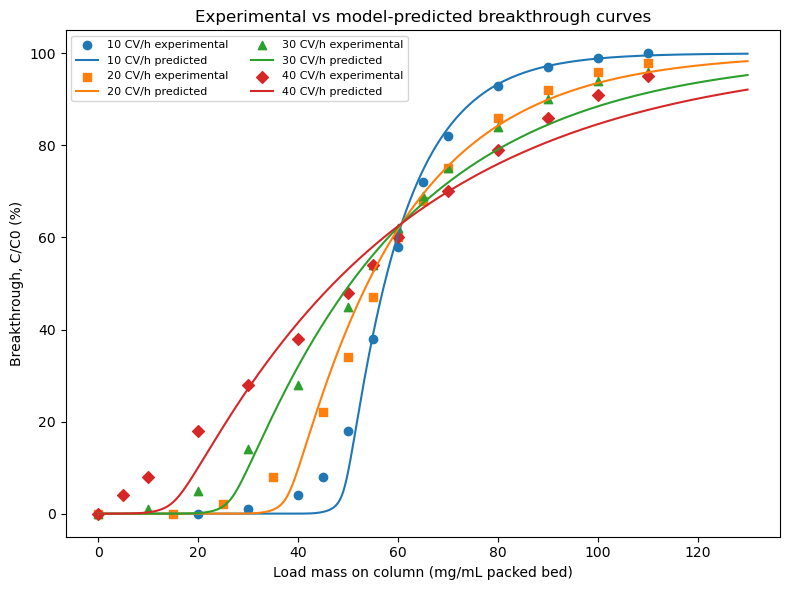


FIT ERROR SUMMARY BY FLOW RATE
               MAE      RMSE      Bias    MaxAbs
CV_per_h                                        
10        2.174773  3.507501 -0.986367  8.948844
20        2.686398  3.491097  0.192146  7.131146
30        3.266169  3.753648 -1.725782  5.514927
40        4.114293  4.859289 -1.949215  7.925327

OBC AT 95% CAPTURE
    residence_time_min  OBC_at_95_capture_mg_mL_bed
0                  1.0                     1.353024
1                  1.5                    16.955518
2                  2.0                    27.640972
3                  2.5                    34.070164
4                  3.0                    38.360948
5                  3.5                    41.427187
6                  4.0                    43.726816
7                  4.5                    45.515719
8                  5.0                    46.945450
9                  5.5                    48.114598
10                 6.0                    49.089485
11                 6.5        

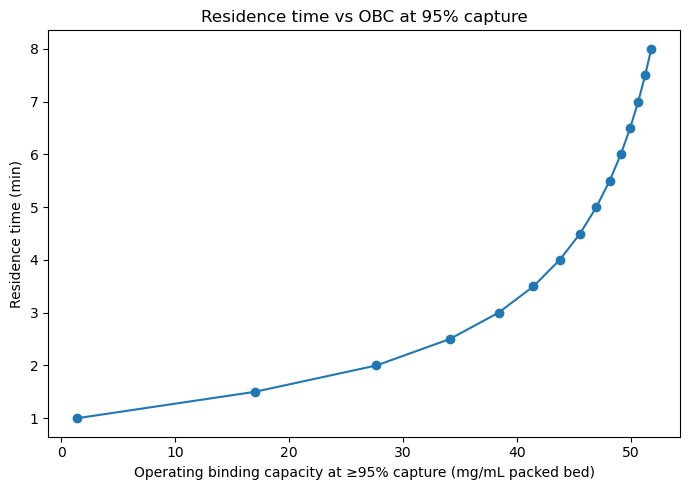


Files saved in:
/Users/vijaymaranholkar/Desktop/Amgen/output


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTDIR = Path("./output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# CASE: MAb1 on MabSelect SuRe
# Approximate digitized breakthrough data from Figure 15.3
# Replace these values with true WebPlotDigitizer/raw data if available.
# ============================================================

digitized_data = {
    10: pd.DataFrame({
        "load_mg_mL_bed": [0, 20, 30, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  1,  4,  8, 18, 38, 58, 72, 82, 93, 97, 99, 100]
    }),
    20: pd.DataFrame({
        "load_mg_mL_bed": [0, 15, 25, 35, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  2,  8, 22, 34, 47, 60, 68, 75, 86, 92, 96, 98]
    }),
    30: pd.DataFrame({
        "load_mg_mL_bed": [0, 10, 20, 30, 40, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  1,  5, 14, 28, 45, 54, 62, 69, 75, 84, 90, 94, 96]
    }),
    40: pd.DataFrame({
        "load_mg_mL_bed": [0, 5, 10, 20, 30, 40, 50, 55, 60, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0, 4,  8, 18, 28, 38, 48, 54, 60, 70, 79, 86, 91, 95]
    })
}

# ============================================================
# COLUMN / FEED CONDITIONS
# ============================================================

feed_conc = 2.52          # mg/mL
column_ID_cm = 1.6
bed_height_cm = 2.5

V_col_mL = np.pi * (column_ID_cm / 2)**2 * bed_height_cm
L_m = bed_height_cm / 100

eps = 0.41                # bed void fraction
dp_m = 85e-6              # particle diameter, m
n_comp = 10

# ============================================================
# MODEL EQUATIONS
# ============================================================

def flow_from_CVh(CV_per_h):
    return CV_per_h * V_col_mL / 60.0


def k_from_Ds(Ds):
    rp = dp_m / 2
    return 15 * Ds / rp**2


def qeq(c, Qmax, b):
    c = np.maximum(c, 0)
    return Qmax * b * c / (1 + b * c)


def rhs_dispersion(t, y, F_mL_min, cfeed, Qmax, b, Ds, Dax):
    N = n_comp

    c = y[:N]
    q = y[N:]

    Vseg_mL = V_col_mL / N
    F_mL_s = F_mL_min / 60
    dz = L_m / N

    c_up = np.empty(N)
    c_up[0] = cfeed
    c_up[1:] = c[:-1]

    c_left = np.empty(N)
    c_right = np.empty(N)

    c_left[0] = cfeed
    c_left[1:] = c[:-1]

    c_right[:-1] = c[1:]
    c_right[-1] = c[-1]

    d2c = (c_left - 2*c + c_right) / dz**2

    k = k_from_Ds(Ds)
    mt = k * (qeq(c, Qmax, b) - q)

    dc = (
        (F_mL_s / (eps * Vseg_mL)) * (c_up - c)
        + (Dax / eps) * d2c
        - ((1 - eps) / eps) * mt
    )

    dq = mt

    return np.r_[dc, dq]


def simulate_breakthrough(CV_per_h, Qmax, b, Ds, Dax, max_load=130, n_points=1000):
    F_mL_min = flow_from_CVh(CV_per_h)

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax, b, Ds, Dax),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = F_mL_min * feed_conc * (sol.t / 60) / V_col_mL

    return pd.DataFrame({
        "CV_per_h": CV_per_h,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


# ============================================================
# GLOBAL FIT TO 10, 20, 30, AND 40 CV/h
# Fit Qmax, b, Ds, Dax
# ============================================================

def residuals(log_params):
    Qmax, b, Ds, Dax = np.exp(log_params)

    if not (70 < Qmax < 180 and 1 < b < 300 and 1e-15 < Ds < 1e-12 and 1e-12 < Dax < 1e-6):
        total_points = sum(len(df) for df in digitized_data.values())
        return np.ones(total_points + 4) * 1e6

    residual_list = []

    for CV_per_h, exp in digitized_data.items():

        sim = simulate_breakthrough(
            CV_per_h,
            Qmax,
            b,
            Ds,
            Dax,
            max_load=130,
            n_points=500
        )

        pred = np.interp(
            exp["load_mg_mL_bed"],
            sim["load_mg_mL_bed"],
            sim["c_over_c0_pct"]
        )

        residual_list.extend(pred - exp["c_over_c0_pct"].values)

    # mild regularization toward paper-like initial values
    reg = [
        0.03 * (np.log(Qmax) - np.log(107)),
        0.03 * (np.log(b) - np.log(44)),
        0.03 * (np.log(Ds) - np.log(9.5e-14)),
        0.03 * (np.log(Dax) - np.log(4.4e-11)),
    ]

    return np.r_[residual_list, reg]


x0 = np.log([107, 44, 9.5e-14, 4.4e-11])

fit = least_squares(
    residuals,
    x0,
    max_nfev=80,
    xtol=1e-4,
    ftol=1e-4
)

Qmax_fit, b_fit, Ds_fit, Dax_fit = np.exp(fit.x)

print("\nBEST-FIT PARAMETERS")
print(f"Qmax = {Qmax_fit:.4f} mg/mL bead")
print(f"b    = {b_fit:.4f} mL/mg")
print(f"Ds   = {Ds_fit:.4e} m^2/s")
print(f"Dax  = {Dax_fit:.4e} m^2/s")
print(f"kLDF = {k_from_Ds(Ds_fit):.4e} 1/s")
print(f"SBC  = {(1-eps)*Qmax_fit:.4f} mg/mL packed bed")

# ============================================================
# ERROR TABLE AND FITTING CURVES
# ============================================================

error_rows = []
model_rows = []

plt.figure(figsize=(8, 6))

markers = {
    10: "o",
    20: "s",
    30: "^",
    40: "D"
}

for CV_per_h, exp in digitized_data.items():

    sim = simulate_breakthrough(
        CV_per_h,
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        max_load=130,
        n_points=1200
    )

    model_rows.append(sim)

    pred = np.interp(
        exp["load_mg_mL_bed"],
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"]
    )

    for x, y_exp, y_pred in zip(exp["load_mg_mL_bed"], exp["c_over_c0_pct"], pred):
        error_rows.append({
            "CV_per_h": CV_per_h,
            "load_mg_mL_bed": x,
            "experimental_C_C0_pct": y_exp,
            "predicted_C_C0_pct": y_pred,
            "error_pctpt": y_pred - y_exp
        })

    plt.scatter(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        marker=markers[CV_per_h],
        label=f"{CV_per_h} CV/h experimental"
    )

    plt.plot(
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"],
        label=f"{CV_per_h} CV/h predicted"
    )

plt.xlabel("Load mass on column (mg/mL packed bed)")
plt.ylabel("Breakthrough, C/C0 (%)")
plt.title("Experimental vs model-predicted breakthrough curves")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

fit_plot_path = OUTDIR / "experimental_vs_predicted_breakthrough_fit.png"
plt.savefig(fit_plot_path, dpi=300)
plt.show()

error_df = pd.DataFrame(error_rows)
model_df = pd.concat(model_rows, ignore_index=True)

print("\nFIT ERROR SUMMARY BY FLOW RATE")
summary = error_df.groupby("CV_per_h")["error_pctpt"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Bias="mean",
    MaxAbs=lambda x: np.max(np.abs(x))
)

print(summary)

# ============================================================
# OBC AT 95% CAPTURE
# 95% capture = 5% breakthrough
# ============================================================

def simulate_breakthrough_RT(residence_time_min, max_load=160, n_points=1200):

    F_mL_min = V_col_mL / residence_time_min

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax_fit, b_fit, Ds_fit, Dax_fit),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = F_mL_min * feed_conc * (sol.t / 60) / V_col_mL

    return pd.DataFrame({
        "residence_time_min": residence_time_min,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


def find_load_at_breakthrough(residence_time_min, breakthrough_pct=5.0):

    sim = simulate_breakthrough_RT(
        residence_time_min,
        max_load=160,
        n_points=1200
    )

    x = sim["load_mg_mL_bed"].values
    y = sim["c_over_c0_pct"].values

    # enforce monotonicity for stable interpolation
    y_mono = np.maximum.accumulate(y)

    if breakthrough_pct < y_mono.min() or breakthrough_pct > y_mono.max():
        return np.nan

    return np.interp(
        breakthrough_pct,
        y_mono,
        x
    )


residence_times = np.arange(1, 8.0 + 0.001, 0.5)

obc_95 = [
    find_load_at_breakthrough(rt, breakthrough_pct=5.0)
    for rt in residence_times
]

obc_df = pd.DataFrame({
    "residence_time_min": residence_times,
    "OBC_at_95_capture_mg_mL_bed": obc_95
})

print("\nOBC AT 95% CAPTURE")
print(obc_df)

# ============================================================
# PLOT OBC VS RT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    obc_df["OBC_at_95_capture_mg_mL_bed"],
    obc_df["residence_time_min"],
    marker="o"
)

plt.xlabel("Operating binding capacity at ≥95% capture (mg/mL packed bed)")
plt.ylabel("Residence time (min)")
plt.title("Residence time vs OBC at 95% capture")
plt.tight_layout()

obc_plot_path = OUTDIR / "rt_vs_obc_95_capture.png"
plt.savefig(obc_plot_path, dpi=300)
plt.show()

# ============================================================
# SAVE OUTPUTS
# ============================================================

params_df = pd.DataFrame({
    "parameter": ["Qmax", "b", "Ds", "Dax", "kLDF", "SBC"],
    "value": [
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        k_from_Ds(Ds_fit),
        (1-eps)*Qmax_fit
    ],
    "unit": [
        "mg/mL bead",
        "mL/mg",
        "m^2/s",
        "m^2/s",
        "1/s",
        "mg/mL packed bed"
    ]
})

params_df.to_csv(OUTDIR / "best_fit_parameters.csv", index=False)
error_df.to_csv(OUTDIR / "experimental_vs_predicted_values.csv", index=False)
model_df.to_csv(OUTDIR / "predicted_breakthrough_curves.csv", index=False)
obc_df.to_csv(OUTDIR / "rt_vs_obc_95_capture.csv", index=False)

print("\nFiles saved in:")
print(OUTDIR.resolve())

# Loading and non loading phases operation time is same


BEST-FIT PARAMETERS
Qmax = 101.7691 mg/mL bead
b    = 47.4290 mL/mg
Ds   = 7.5816e-14 m²/s
Dax  = 3.6202e-11 m²/s
kLDF = 6.2962e-04 1/s
SBC  = 60.0438 mg/mL packed bed


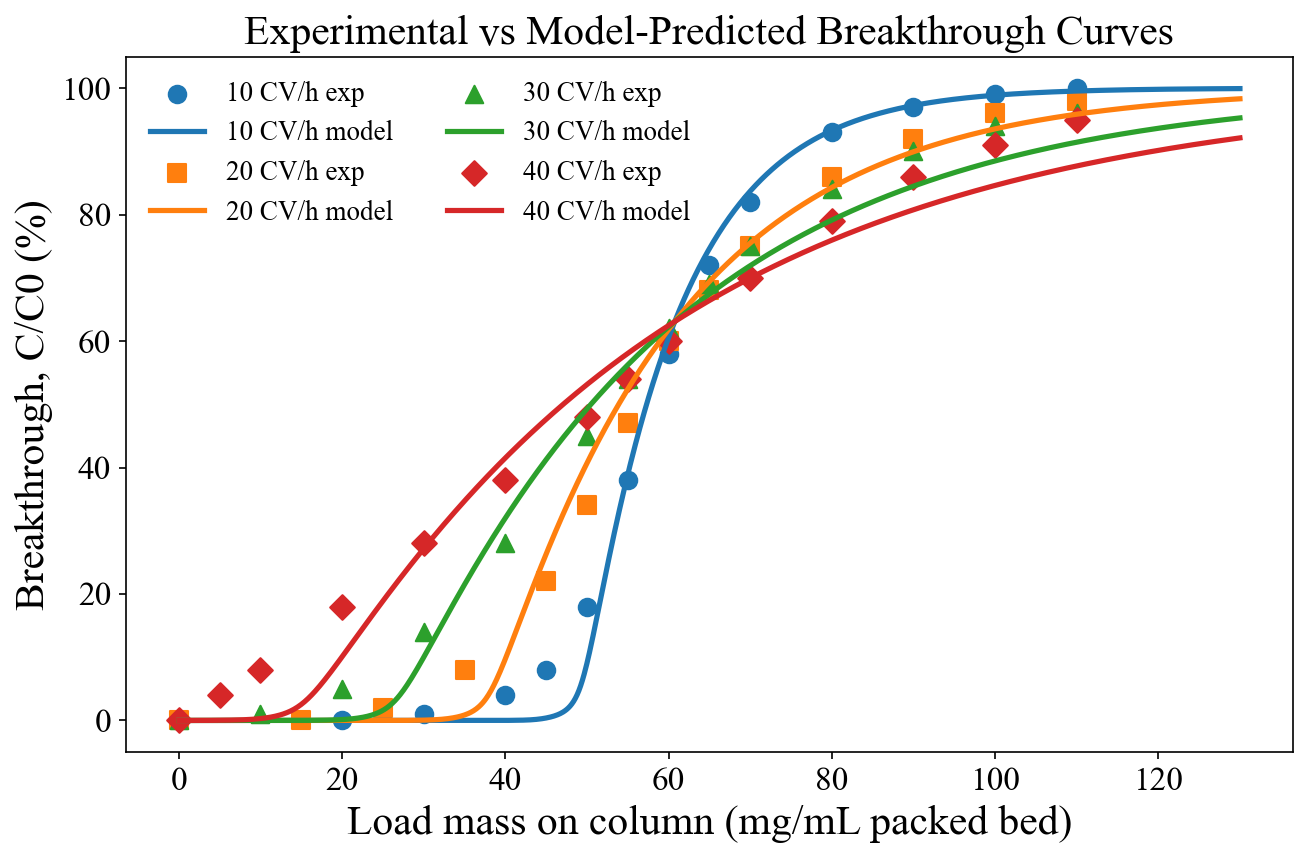


FIT ERROR SUMMARY BY FLOW RATE
               MAE      RMSE      Bias    MaxAbs
CV_per_h                                        
10        2.174773  3.507501 -0.986367  8.948844
20        2.686398  3.491097  0.192146  7.131146
30        3.266169  3.753648 -1.725782  5.514927
40        4.114293  4.859289 -1.949215  7.925327

TWO-COLUMN PRODUCTIVITY AND UTILIZATION
 residence_time_min  OBC_at_95_capture_mg_mL_bed  adsorbent_capacity_utilization_pct  t_load_min  t_nonload_min  cycle_time_min  productivity_captured_g_L_total_resin_h  productivity_processed_g_L_total_resin_h
                0.5                        0.824                               1.372       0.163          0.163           0.163                                  143.640                                   151.200
                1.0                        1.353                               2.253       0.537          0.537           0.537                                   71.820                                    75.600


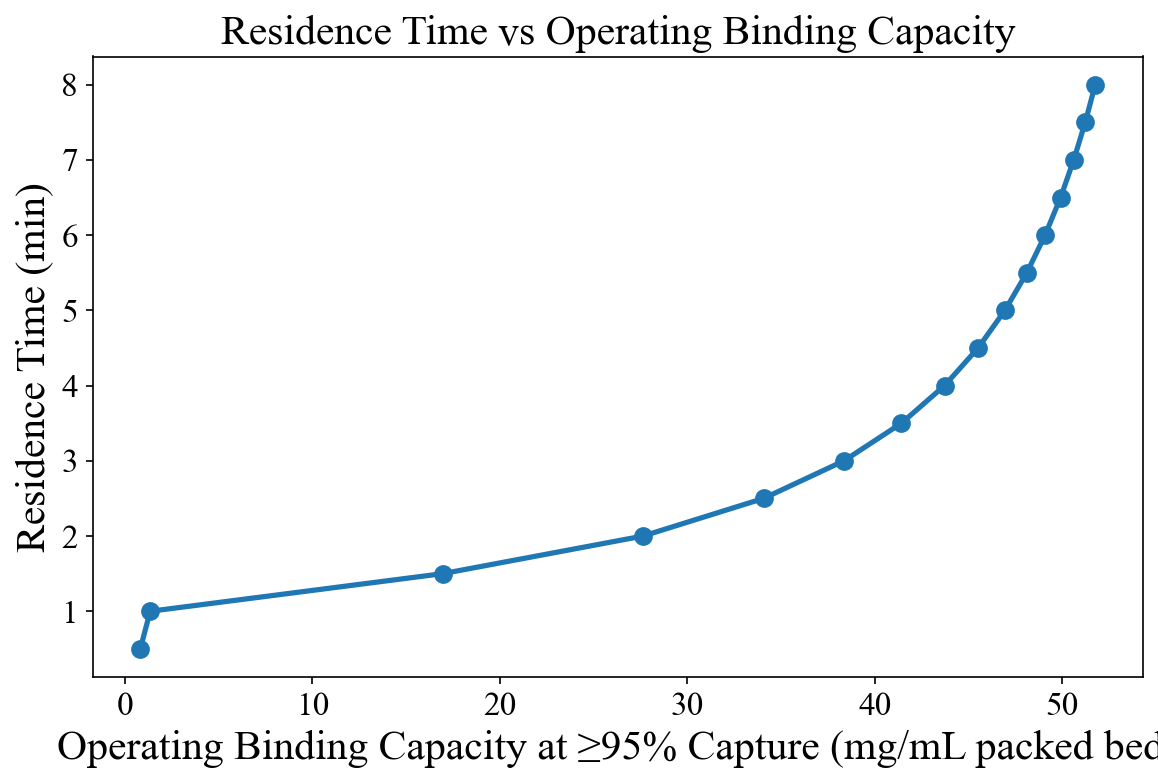

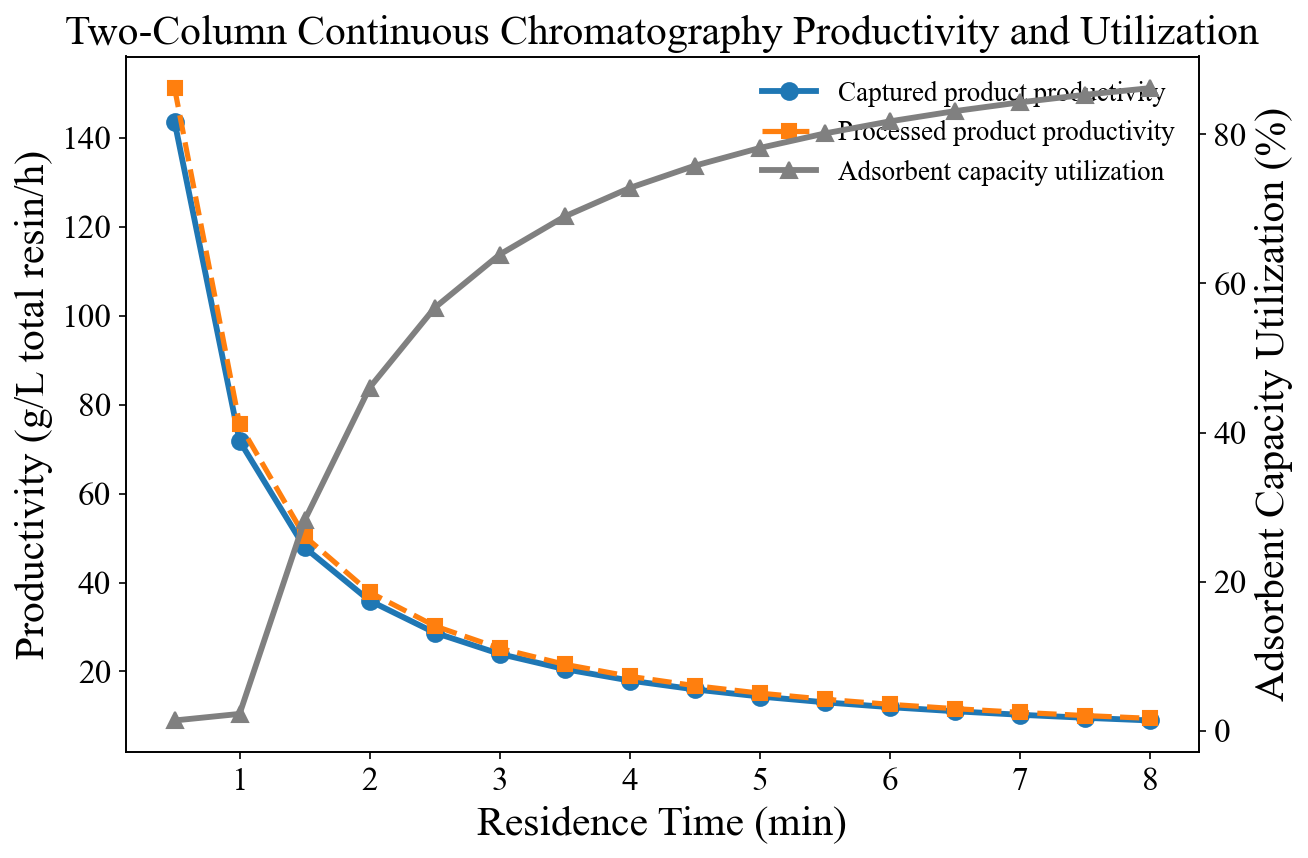


Files saved in:
/Users/vijaymaranholkar/Desktop/Amgen/output
output/experimental_vs_predicted_breakthrough_fit_PPT.png
output/RT_vs_OBC_95_capture_PPT.png
output/Productivity_and_Utilization_vs_RT_PPT.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# GLOBAL PLOT STYLE FOR PPT
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["figure.dpi"] = 150

# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTDIR = Path("./output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DIGITIZED BREAKTHROUGH DATA
# ============================================================

digitized_data = {
    10: pd.DataFrame({
        "load_mg_mL_bed": [0, 20, 30, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  1,  4,  8, 18, 38, 58, 72, 82, 93, 97, 99, 100]
    }),
    20: pd.DataFrame({
        "load_mg_mL_bed": [0, 15, 25, 35, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  2,  8, 22, 34, 47, 60, 68, 75, 86, 92, 96, 98]
    }),
    30: pd.DataFrame({
        "load_mg_mL_bed": [0, 10, 20, 30, 40, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  1,  5, 14, 28, 45, 54, 62, 69, 75, 84, 90, 94, 96]
    }),
    40: pd.DataFrame({
        "load_mg_mL_bed": [0, 5, 10, 20, 30, 40, 50, 55, 60, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0, 4,  8, 18, 28, 38, 48, 54, 60, 70, 79, 86, 91, 95]
    })
}

# ============================================================
# COLUMN AND FEED CONDITIONS
# ============================================================

feed_conc = 2.52          # mg/mL = g/L
capture_efficiency = 0.95

column_ID_cm = 1.6
bed_height_cm = 2.5

V_col_mL = np.pi * (column_ID_cm / 2)**2 * bed_height_cm
L_m = bed_height_cm / 100

eps = 0.41
dp_m = 85e-6
n_comp = 10

# ============================================================
# MODEL EQUATIONS
# ============================================================

def flow_from_CVh(CV_per_h):
    return CV_per_h * V_col_mL / 60.0


def k_from_Ds(Ds):
    rp = dp_m / 2
    return 15 * Ds / rp**2


def qeq(c, Qmax, b):
    c = np.maximum(c, 0)
    return Qmax * b * c / (1 + b * c)


def rhs_dispersion(t, y, F_mL_min, cfeed, Qmax, b, Ds, Dax):
    N = n_comp
    c = y[:N]
    q = y[N:]

    Vseg_mL = V_col_mL / N
    F_mL_s = F_mL_min / 60.0
    dz = L_m / N

    # Convection
    c_up = np.empty(N)
    c_up[0] = cfeed
    c_up[1:] = c[:-1]

    # Axial dispersion
    c_left = np.empty(N)
    c_right = np.empty(N)

    c_left[0] = cfeed
    c_left[1:] = c[:-1]

    c_right[:-1] = c[1:]
    c_right[-1] = c[-1]

    d2c = (c_left - 2*c + c_right) / dz**2

    # LDF adsorption
    k = k_from_Ds(Ds)
    mt = k * (qeq(c, Qmax, b) - q)

    dc = (
        (F_mL_s / (eps * Vseg_mL)) * (c_up - c)
        + (Dax / eps) * d2c
        - ((1 - eps) / eps) * mt
    )

    dq = mt

    return np.r_[dc, dq]


def simulate_breakthrough(CV_per_h, Qmax, b, Ds, Dax, max_load=130, n_points=1000):
    F_mL_min = flow_from_CVh(CV_per_h)

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax, b, Ds, Dax),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]
    load = F_mL_min * feed_conc * (sol.t / 60) / V_col_mL

    return pd.DataFrame({
        "CV_per_h": CV_per_h,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })

# ============================================================
# GLOBAL FIT
# ============================================================

def residuals(log_params):
    Qmax, b, Ds, Dax = np.exp(log_params)

    if not (70 < Qmax < 180 and 1 < b < 300 and 1e-15 < Ds < 1e-12 and 1e-12 < Dax < 1e-6):
        total_points = sum(len(df) for df in digitized_data.values())
        return np.ones(total_points + 4) * 1e6

    residual_list = []

    for CV_per_h, exp in digitized_data.items():
        sim = simulate_breakthrough(
            CV_per_h,
            Qmax,
            b,
            Ds,
            Dax,
            max_load=130,
            n_points=500
        )

        pred = np.interp(
            exp["load_mg_mL_bed"],
            sim["load_mg_mL_bed"],
            sim["c_over_c0_pct"]
        )

        residual_list.extend(pred - exp["c_over_c0_pct"].values)

    reg = [
        0.03 * (np.log(Qmax) - np.log(107)),
        0.03 * (np.log(b) - np.log(44)),
        0.03 * (np.log(Ds) - np.log(9.5e-14)),
        0.03 * (np.log(Dax) - np.log(4.4e-11)),
    ]

    return np.r_[residual_list, reg]


x0 = np.log([107, 44, 9.5e-14, 4.4e-11])

fit = least_squares(
    residuals,
    x0,
    max_nfev=80,
    xtol=1e-4,
    ftol=1e-4
)

Qmax_fit, b_fit, Ds_fit, Dax_fit = np.exp(fit.x)
SBC_mg_mL_bed = (1 - eps) * Qmax_fit

print("\nBEST-FIT PARAMETERS")
print(f"Qmax = {Qmax_fit:.4f} mg/mL bead")
print(f"b    = {b_fit:.4f} mL/mg")
print(f"Ds   = {Ds_fit:.4e} m²/s")
print(f"Dax  = {Dax_fit:.4e} m²/s")
print(f"kLDF = {k_from_Ds(Ds_fit):.4e} 1/s")
print(f"SBC  = {SBC_mg_mL_bed:.4f} mg/mL packed bed")

# ============================================================
# BREAKTHROUGH FITTING PLOT
# ============================================================

error_rows = []
model_rows = []

fig, ax = plt.subplots(figsize=(9, 6))

markers = {10: "o", 20: "s", 30: "^", 40: "D"}

for CV_per_h, exp in digitized_data.items():

    sim = simulate_breakthrough(
        CV_per_h,
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        max_load=130,
        n_points=1200
    )

    model_rows.append(sim)

    pred = np.interp(
        exp["load_mg_mL_bed"],
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"]
    )

    for x, y_exp, y_pred in zip(exp["load_mg_mL_bed"], exp["c_over_c0_pct"], pred):
        error_rows.append({
            "CV_per_h": CV_per_h,
            "load_mg_mL_bed": x,
            "experimental_C_C0_pct": y_exp,
            "predicted_C_C0_pct": y_pred,
            "error_pctpt": y_pred - y_exp
        })

    ax.scatter(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        marker=markers[CV_per_h],
        s=70,
        label=f"{CV_per_h} CV/h exp"
    )

    ax.plot(
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"],
        linewidth=2.5,
        label=f"{CV_per_h} CV/h model"
    )

ax.set_xlabel("Load mass on column (mg/mL packed bed)")
ax.set_ylabel("Breakthrough, C/C0 (%)")
ax.set_title("Experimental vs Model-Predicted Breakthrough Curves")
ax.legend(ncol=2, frameon=False)
ax.grid(False)

plt.tight_layout()
fit_plot_path = OUTDIR / "experimental_vs_predicted_breakthrough_fit_PPT.png"
plt.savefig(fit_plot_path, dpi=300, bbox_inches="tight")
plt.show()

error_df = pd.DataFrame(error_rows)
model_df = pd.concat(model_rows, ignore_index=True)

print("\nFIT ERROR SUMMARY BY FLOW RATE")
summary = error_df.groupby("CV_per_h")["error_pctpt"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Bias="mean",
    MaxAbs=lambda x: np.max(np.abs(x))
)
print(summary)

# ============================================================
# OBC AT 95% CAPTURE
# ============================================================

def simulate_breakthrough_RT(residence_time_min, max_load=160, n_points=1200):

    F_mL_min = V_col_mL / residence_time_min

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax_fit, b_fit, Ds_fit, Dax_fit),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]
    load = F_mL_min * feed_conc * (sol.t / 60) / V_col_mL

    return pd.DataFrame({
        "residence_time_min": residence_time_min,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


def find_load_at_breakthrough(residence_time_min, breakthrough_pct=5.0):

    sim = simulate_breakthrough_RT(
        residence_time_min,
        max_load=160,
        n_points=1200
    )

    x = sim["load_mg_mL_bed"].values
    y = sim["c_over_c0_pct"].values

    y_mono = np.maximum.accumulate(y)

    if breakthrough_pct < y_mono.min() or breakthrough_pct > y_mono.max():
        return np.nan

    return np.interp(breakthrough_pct, y_mono, x)


residence_times = np.arange(0.5, 8.0 + 0.001, 0.5)

obc_95 = [
    find_load_at_breakthrough(rt, breakthrough_pct=5.0)
    for rt in residence_times
]

obc_df = pd.DataFrame({
    "residence_time_min": residence_times,
    "OBC_at_95_capture_mg_mL_bed": obc_95
})

# ============================================================
# TWO-COLUMN CONTINUOUS PRODUCTIVITY
# Assumption: one column loading and one column non-loading.
# t_nonload = t_load, no idle time.
# Productivity normalized by total resin volume in two columns.
# ============================================================

obc_df["adsorbent_capacity_utilization_pct"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"] / SBC_mg_mL_bed * 100
)

obc_df["t_load_min"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * obc_df["residence_time_min"]
    / feed_conc
)

obc_df["t_nonload_min"] = obc_df["t_load_min"]
obc_df["cycle_time_min"] = obc_df["t_load_min"]

obc_df["productivity_captured_g_L_total_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * capture_efficiency
    * 60
    / (2 * obc_df["cycle_time_min"])
)

obc_df["productivity_processed_g_L_total_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * 60
    / (2 * obc_df["cycle_time_min"])
)

print("\nTWO-COLUMN PRODUCTIVITY AND UTILIZATION")
print(obc_df.round(3).to_string(index=False))

# ============================================================
# PLOT 1: RT VS OBC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    obc_df["OBC_at_95_capture_mg_mL_bed"],
    obc_df["residence_time_min"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.set_xlabel("Operating Binding Capacity at ≥95% Capture (mg/mL packed bed)")
ax.set_ylabel("Residence Time (min)")
ax.set_title("Residence Time vs Operating Binding Capacity")
ax.grid(False)

plt.tight_layout()
obc_plot_path = OUTDIR / "RT_vs_OBC_95_capture_PPT.png"
plt.savefig(obc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: PRODUCTIVITY + UTILIZATION SECONDARY AXIS
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["productivity_captured_g_L_total_resin_h"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Captured product productivity"
)

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["productivity_processed_g_L_total_resin_h"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Processed product productivity"
)

ax1.set_xlabel("Residence Time (min)")
ax1.set_ylabel("Productivity (g/L total resin/h)")
ax1.grid(False)

ax2 = ax1.twinx()

ax2.plot(
    obc_df["residence_time_min"],
    obc_df["adsorbent_capacity_utilization_pct"],
    marker="^",
    linewidth=2.8,
    markersize=8,
    color="gray",
    label="Adsorbent capacity utilization"
)

ax2.set_ylabel("Adsorbent Capacity Utilization (%)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="best"
)

plt.title("Two-Column Continuous Chromatography Productivity and Utilization")
plt.tight_layout()

prod_util_plot_path = OUTDIR / "Productivity_and_Utilization_vs_RT_PPT.png"
plt.savefig(prod_util_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SAVE OUTPUTS
# ============================================================

params_df = pd.DataFrame({
    "parameter": ["Qmax", "b", "Ds", "Dax", "kLDF", "SBC"],
    "value": [
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        k_from_Ds(Ds_fit),
        SBC_mg_mL_bed
    ],
    "unit": [
        "mg/mL bead",
        "mL/mg",
        "m²/s",
        "m²/s",
        "1/s",
        "mg/mL packed bed"
    ]
})

params_df.to_csv(OUTDIR / "best_fit_parameters.csv", index=False)
error_df.to_csv(OUTDIR / "experimental_vs_predicted_values.csv", index=False)
model_df.to_csv(OUTDIR / "predicted_breakthrough_curves.csv", index=False)
obc_df.to_csv(OUTDIR / "two_column_productivity_utilization_vs_RT.csv", index=False)

print("\nFiles saved in:")
print(OUTDIR.resolve())
print(fit_plot_path)
print(obc_plot_path)
print(prod_util_plot_path)

# Const. non-loading time 2h; Loading time is dependent on the OBC and RT


BEST-FIT PARAMETERS
Qmax = 101.7691 mg/mL bead
b    = 47.4290 mL/mg
Ds   = 7.5816e-14 m²/s
Dax  = 3.6202e-11 m²/s
kLDF = 6.2962e-04 1/s
SBC  = 60.0438 mg/mL packed bed


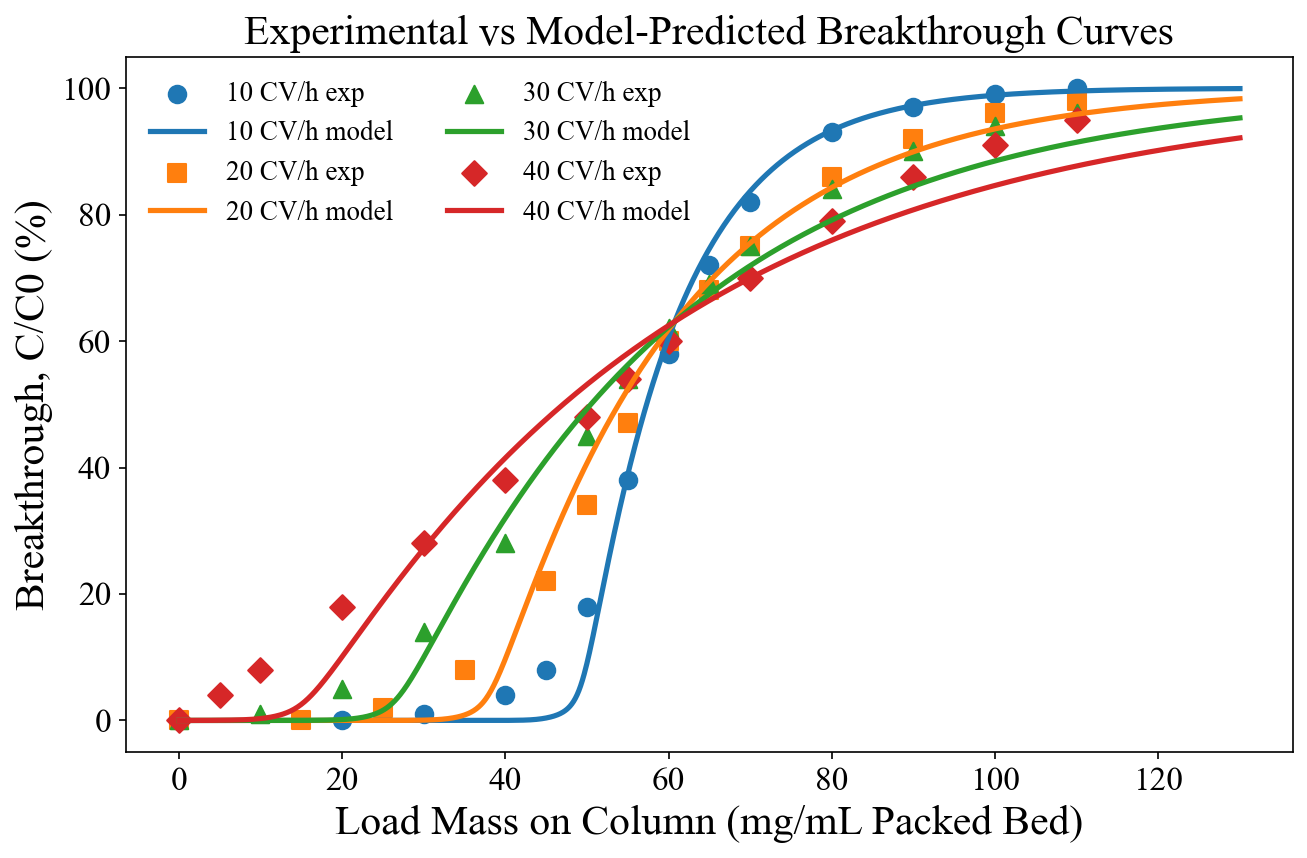


FIT ERROR SUMMARY BY FLOW RATE
               MAE      RMSE      Bias    MaxAbs
CV_per_h                                        
10        2.174773  3.507501 -0.986367  8.948844
20        2.686398  3.491097  0.192146  7.131146
30        3.266169  3.753648 -1.725782  5.514927
40        4.114293  4.859289 -1.949215  7.925327

TWO-COLUMN PRODUCTIVITY WITH FIXED 2 h NON-LOADING TIME
 residence_time_min  OBC_at_95_capture_mg_mL_bed  adsorbent_capacity_utilization_pct  t_load_min  t_nonload_fixed_min  effective_cycle_time_min  idle_or_wait_time_min  productivity_captured_g_L_total_resin_h  productivity_processed_g_L_total_resin_h  captured_product_16h_g_L_total_resin
                0.5                        0.824                               1.372       0.163                  120                   120.000                119.837                                    0.196                                     0.206                                 3.129
                1.0                      

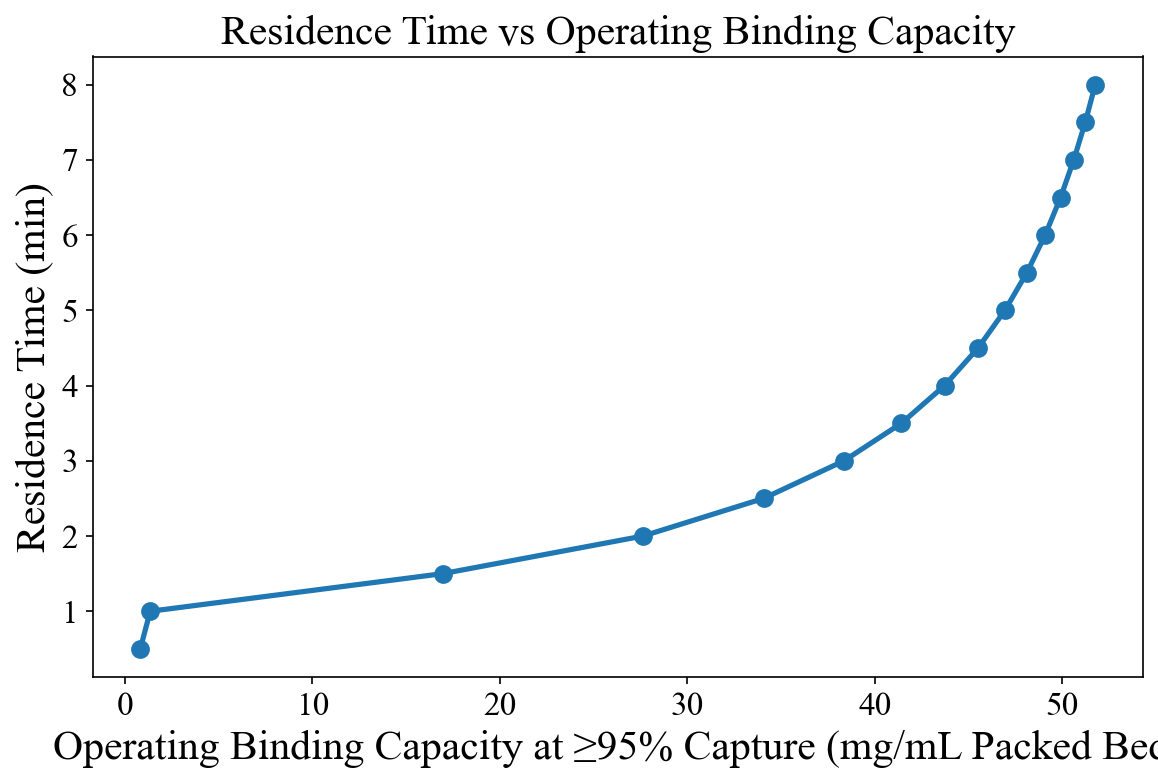

    residence_time_min  OBC_at_95_capture_mg_mL_bed  \
0                  0.5                        0.824   
1                  1.0                        1.353   
2                  1.5                       16.956   
3                  2.0                       27.641   
4                  2.5                       34.070   
5                  3.0                       38.361   
6                  3.5                       41.427   
7                  4.0                       43.727   
8                  4.5                       45.516   
9                  5.0                       46.945   
10                 5.5                       48.115   
11                 6.0                       49.089   
12                 6.5                       49.914   
13                 7.0                       50.619   
14                 7.5                       51.231   
15                 8.0                       51.766   

    adsorbent_capacity_utilization_pct  t_load_min  t_nonload_mi

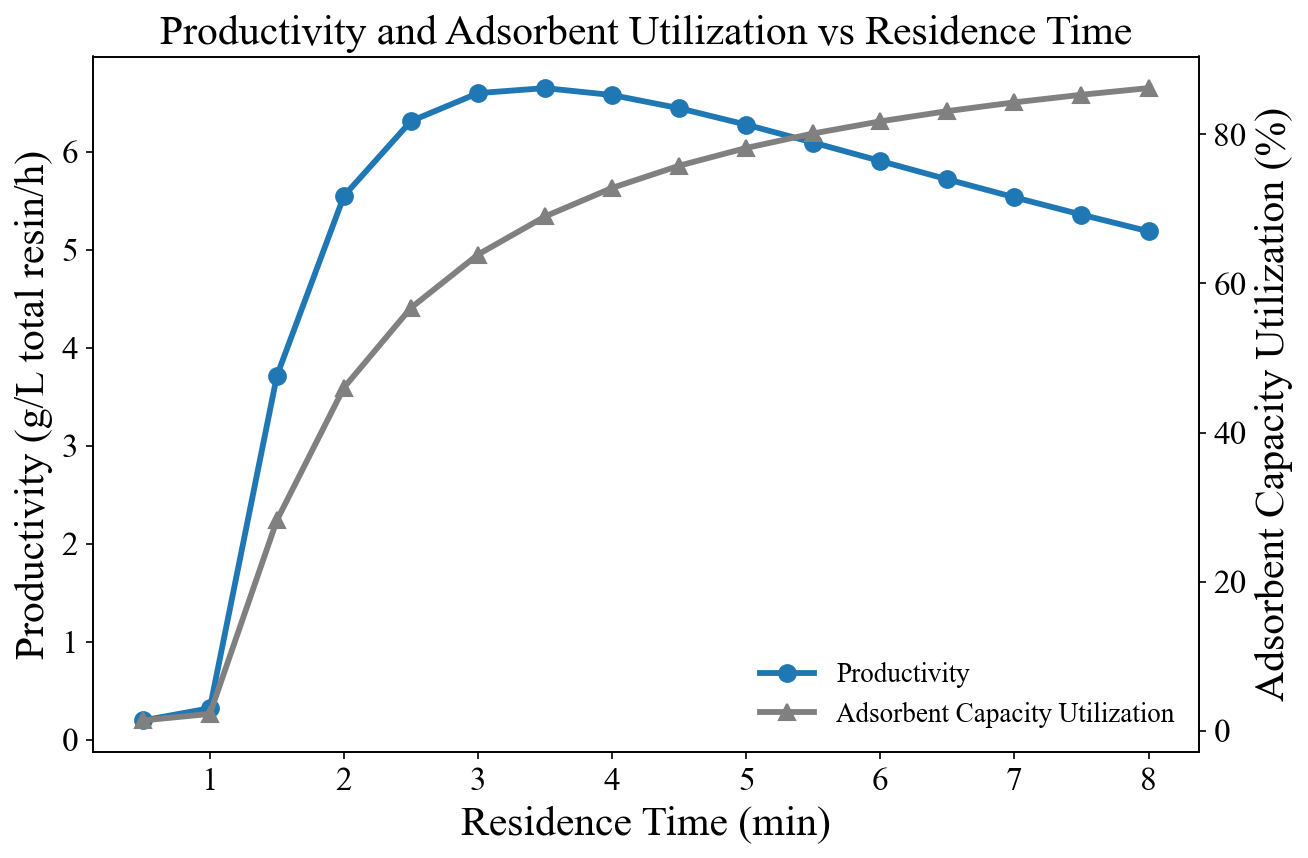

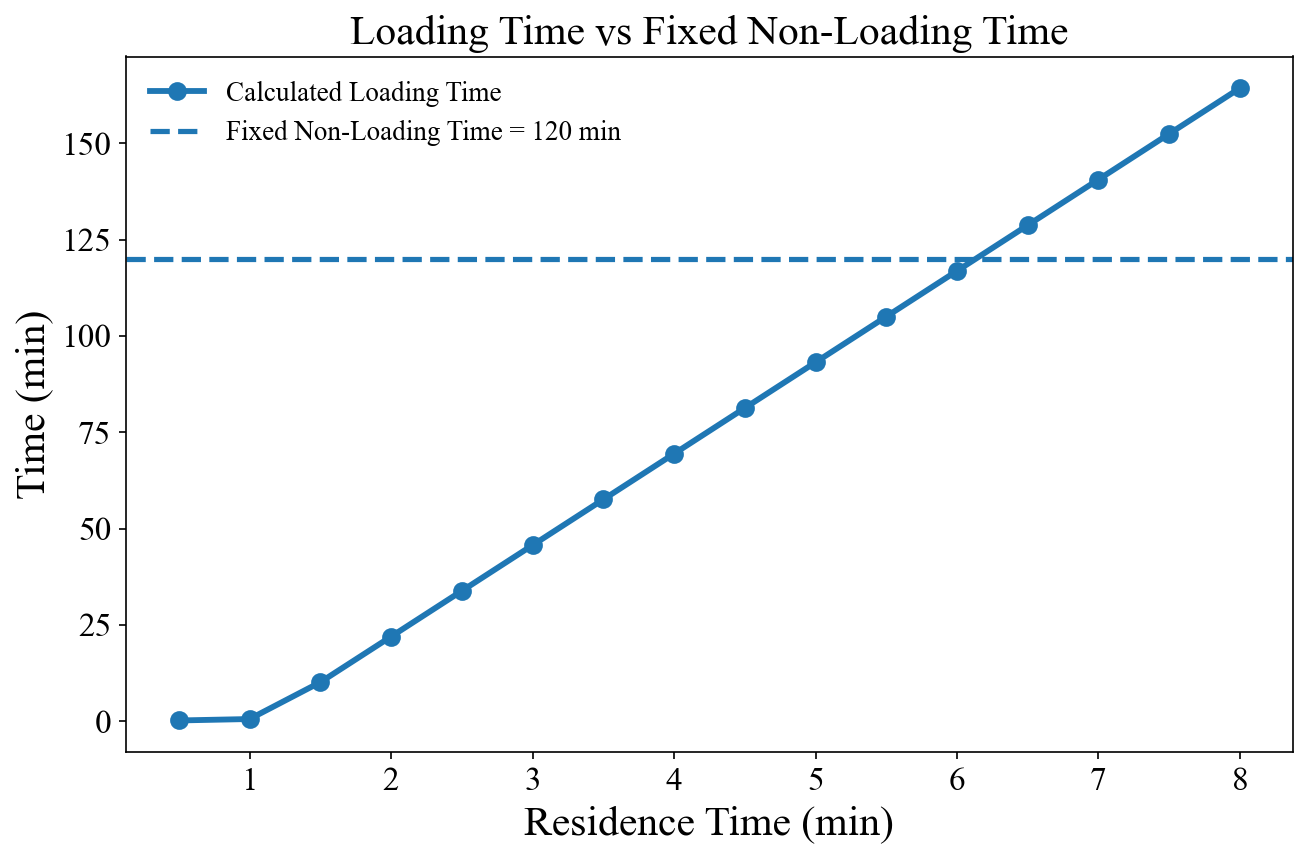


Files saved in:
/Users/vijaymaranholkar/Desktop/Amgen/output
output/experimental_vs_predicted_breakthrough_fit_PPT.png
output/RT_vs_OBC_95_capture_PPT.png
output/Productivity_and_Utilization_vs_RT_fixed_2h_PPT.png
output/Loading_Time_vs_Fixed_Nonload_Time_PPT.png


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# GLOBAL PLOT STYLE FOR PPT
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["figure.dpi"] = 150

# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTDIR = Path("./output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DIGITIZED BREAKTHROUGH DATA
# MAb1 on MabSelect SuRe
# Approximate digitized data from Figure 15.3
# ============================================================

digitized_data = {
    10: pd.DataFrame({
        "load_mg_mL_bed": [0, 20, 30, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  1,  4,  8, 18, 38, 58, 72, 82, 93, 97, 99, 100]
    }),
    20: pd.DataFrame({
        "load_mg_mL_bed": [0, 15, 25, 35, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  2,  8, 22, 34, 47, 60, 68, 75, 86, 92, 96, 98]
    }),
    30: pd.DataFrame({
        "load_mg_mL_bed": [0, 10, 20, 30, 40, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  1,  5, 14, 28, 45, 54, 62, 69, 75, 84, 90, 94, 96]
    }),
    40: pd.DataFrame({
        "load_mg_mL_bed": [0, 5, 10, 20, 30, 40, 50, 55, 60, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0, 4,  8, 18, 28, 38, 48, 54, 60, 70, 79, 86, 91, 95]
    })
}

# ============================================================
# COLUMN AND FEED CONDITIONS
# ============================================================

feed_conc = 2.52          # mg/mL = g/L
capture_efficiency = 0.95

column_ID_cm = 1.6
bed_height_cm = 2.5

V_col_mL = np.pi * (column_ID_cm / 2)**2 * bed_height_cm
L_m = bed_height_cm / 100

eps = 0.41                # bed void fraction
dp_m = 85e-6              # particle diameter, m
n_comp = 10

# Fixed non-loading time for the two-column scenario
t_nonload_fixed_min = 120   # 2 h

# ============================================================
# MODEL EQUATIONS
# ============================================================

def flow_from_CVh(CV_per_h):
    return CV_per_h * V_col_mL / 60.0


def k_from_Ds(Ds):
    rp = dp_m / 2
    return 15 * Ds / rp**2


def qeq(c, Qmax, b):
    c = np.maximum(c, 0)
    return Qmax * b * c / (1 + b * c)


def rhs_dispersion(t, y, F_mL_min, cfeed, Qmax, b, Ds, Dax):
    N = n_comp

    c = y[:N]
    q = y[N:]

    Vseg_mL = V_col_mL / N
    F_mL_s = F_mL_min / 60.0
    dz = L_m / N

    # Convection
    c_up = np.empty(N)
    c_up[0] = cfeed
    c_up[1:] = c[:-1]

    # Axial dispersion
    c_left = np.empty(N)
    c_right = np.empty(N)

    c_left[0] = cfeed
    c_left[1:] = c[:-1]

    c_right[:-1] = c[1:]
    c_right[-1] = c[-1]

    d2c = (c_left - 2*c + c_right) / dz**2

    # LDF adsorption
    k = k_from_Ds(Ds)
    mt = k * (qeq(c, Qmax, b) - q)

    dc = (
        (F_mL_s / (eps * Vseg_mL)) * (c_up - c)
        + (Dax / eps) * d2c
        - ((1 - eps) / eps) * mt
    )

    dq = mt

    return np.r_[dc, dq]


def simulate_breakthrough(CV_per_h, Qmax, b, Ds, Dax, max_load=130, n_points=1000):
    F_mL_min = flow_from_CVh(CV_per_h)

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(
        0,
        t_end_min * 60,
        n_points
    )

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax, b, Ds, Dax),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "CV_per_h": CV_per_h,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })

# ============================================================
# GLOBAL FIT TO 10, 20, 30, AND 40 CV/h
# Fit Qmax, b, Ds, and Dax
# ============================================================

def residuals(log_params):
    Qmax, b, Ds, Dax = np.exp(log_params)

    if not (
        70 < Qmax < 180 and
        1 < b < 300 and
        1e-15 < Ds < 1e-12 and
        1e-12 < Dax < 1e-6
    ):
        total_points = sum(len(df) for df in digitized_data.values())
        return np.ones(total_points + 4) * 1e6

    residual_list = []

    for CV_per_h, exp in digitized_data.items():

        sim = simulate_breakthrough(
            CV_per_h,
            Qmax,
            b,
            Ds,
            Dax,
            max_load=130,
            n_points=500
        )

        pred = np.interp(
            exp["load_mg_mL_bed"],
            sim["load_mg_mL_bed"],
            sim["c_over_c0_pct"]
        )

        residual_list.extend(
            pred - exp["c_over_c0_pct"].values
        )

    # Mild regularization toward literature-like values
    reg = [
        0.03 * (np.log(Qmax) - np.log(107)),
        0.03 * (np.log(b) - np.log(44)),
        0.03 * (np.log(Ds) - np.log(9.5e-14)),
        0.03 * (np.log(Dax) - np.log(4.4e-11)),
    ]

    return np.r_[residual_list, reg]


x0 = np.log([107, 44, 9.5e-14, 4.4e-11])

fit = least_squares(
    residuals,
    x0,
    max_nfev=80,
    xtol=1e-4,
    ftol=1e-4
)

Qmax_fit, b_fit, Ds_fit, Dax_fit = np.exp(fit.x)

SBC_mg_mL_bed = (1 - eps) * Qmax_fit

print("\nBEST-FIT PARAMETERS")
print(f"Qmax = {Qmax_fit:.4f} mg/mL bead")
print(f"b    = {b_fit:.4f} mL/mg")
print(f"Ds   = {Ds_fit:.4e} m²/s")
print(f"Dax  = {Dax_fit:.4e} m²/s")
print(f"kLDF = {k_from_Ds(Ds_fit):.4e} 1/s")
print(f"SBC  = {SBC_mg_mL_bed:.4f} mg/mL packed bed")

# ============================================================
# BREAKTHROUGH FITTING PLOT
# ============================================================

error_rows = []
model_rows = []

fig, ax = plt.subplots(figsize=(9, 6))

markers = {
    10: "o",
    20: "s",
    30: "^",
    40: "D"
}

for CV_per_h, exp in digitized_data.items():

    sim = simulate_breakthrough(
        CV_per_h,
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        max_load=130,
        n_points=1200
    )

    model_rows.append(sim)

    pred = np.interp(
        exp["load_mg_mL_bed"],
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"]
    )

    for x, y_exp, y_pred in zip(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        pred
    ):
        error_rows.append({
            "CV_per_h": CV_per_h,
            "load_mg_mL_bed": x,
            "experimental_C_C0_pct": y_exp,
            "predicted_C_C0_pct": y_pred,
            "error_pctpt": y_pred - y_exp
        })

    ax.scatter(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        marker=markers[CV_per_h],
        s=70,
        label=f"{CV_per_h} CV/h exp"
    )

    ax.plot(
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"],
        linewidth=2.5,
        label=f"{CV_per_h} CV/h model"
    )

ax.set_xlabel("Load Mass on Column (mg/mL Packed Bed)")
ax.set_ylabel("Breakthrough, C/C0 (%)")
ax.set_title("Experimental vs Model-Predicted Breakthrough Curves")
ax.legend(ncol=2, frameon=False)
ax.grid(False)

plt.tight_layout()
fit_plot_path = OUTDIR / "experimental_vs_predicted_breakthrough_fit_PPT.png"
plt.savefig(fit_plot_path, dpi=300, bbox_inches="tight")
plt.show()

error_df = pd.DataFrame(error_rows)
model_df = pd.concat(model_rows, ignore_index=True)

print("\nFIT ERROR SUMMARY BY FLOW RATE")
summary = error_df.groupby("CV_per_h")["error_pctpt"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Bias="mean",
    MaxAbs=lambda x: np.max(np.abs(x))
)
print(summary)

# ============================================================
# OBC AT 95% CAPTURE
# 95% capture = 5% breakthrough
# ============================================================

def simulate_breakthrough_RT(residence_time_min, max_load=160, n_points=1200):

    F_mL_min = V_col_mL / residence_time_min

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(
        0,
        t_end_min * 60,
        n_points
    )

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax_fit, b_fit, Ds_fit, Dax_fit),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "residence_time_min": residence_time_min,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


def find_load_at_breakthrough(residence_time_min, breakthrough_pct=5.0):

    sim = simulate_breakthrough_RT(
        residence_time_min,
        max_load=160,
        n_points=1200
    )

    x = sim["load_mg_mL_bed"].values
    y = sim["c_over_c0_pct"].values

    # Enforce monotonicity for stable interpolation
    y_mono = np.maximum.accumulate(y)

    if breakthrough_pct < y_mono.min() or breakthrough_pct > y_mono.max():
        return np.nan

    return np.interp(
        breakthrough_pct,
        y_mono,
        x
    )


# RT range
residence_times = np.arange(0.5, 8.0 + 0.001, 0.5)

obc_95 = [
    find_load_at_breakthrough(
        rt,
        breakthrough_pct=5.0
    )
    for rt in residence_times
]

obc_df = pd.DataFrame({
    "residence_time_min": residence_times,
    "OBC_at_95_capture_mg_mL_bed": obc_95
})

# ============================================================
# TWO-COLUMN PRODUCTIVITY WITH FIXED 2 h NON-LOADING TIME
# Scenario:
# - One column loading
# - One column in non-loading zone
# - Non-loading phase takes fixed 2 h = 120 min
# - If t_load < 120 min, loading column waits
# - Productivity normalized by total resin in both columns
# ============================================================

obc_df["adsorbent_capacity_utilization_pct"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    / SBC_mg_mL_bed
    * 100
)

# Loading time required to reach OBC:
# OBC mg/mL resin = g/L resin
# feed_conc mg/mL = g/L
obc_df["t_load_min"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * obc_df["residence_time_min"]
    / feed_conc
)

obc_df["t_nonload_fixed_min"] = t_nonload_fixed_min

# Effective cycle time for alternating two-column operation
obc_df["effective_cycle_time_min"] = np.maximum(
    obc_df["t_load_min"],
    obc_df["t_nonload_fixed_min"]
)

obc_df["idle_or_wait_time_min"] = (
    obc_df["effective_cycle_time_min"]
    - obc_df["t_load_min"]
)

# Captured product productivity
# Divide by 2 because total resin volume = two columns
obc_df["productivity_captured_g_L_total_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * capture_efficiency
    * 60
    / (2 * obc_df["effective_cycle_time_min"])
)

# Processed-product productivity before capture correction
obc_df["productivity_processed_g_L_total_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * 60
    / (2 * obc_df["effective_cycle_time_min"])
)

# Product captured during 16 h run per L total resin
obc_df["captured_product_16h_g_L_total_resin"] = (
    obc_df["productivity_captured_g_L_total_resin_h"]
    * 16
)

print("\nTWO-COLUMN PRODUCTIVITY WITH FIXED 2 h NON-LOADING TIME")
print(obc_df.round(3).to_string(index=False))

best_row = obc_df.loc[
    obc_df["productivity_captured_g_L_total_resin_h"].idxmax()
]

print("\nBEST PRODUCTIVITY CONDITION")
print(best_row.round(3).to_string())

# ============================================================
# PLOT 1: RT VS OBC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    obc_df["OBC_at_95_capture_mg_mL_bed"],
    obc_df["residence_time_min"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.set_xlabel("Operating Binding Capacity at ≥95% Capture (mg/mL Packed Bed)")
ax.set_ylabel("Residence Time (min)")
ax.set_title("Residence Time vs Operating Binding Capacity")
ax.grid(False)

plt.tight_layout()
obc_plot_path = OUTDIR / "RT_vs_OBC_95_capture_PPT.png"
plt.savefig(obc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

##++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# ============================================================
# PRODUCTIVITY WITH CONSTANT NON-LOADING TIME = 2 h
# User-confirmed method:
# Productivity = OBC / (loading time + non-loading time)
# ============================================================

capture_efficiency = 0.95
t_nonload_fixed_min = 120  # 2 h

obc_df["adsorbent_capacity_utilization_pct"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"] / SBC_mg_mL_bed * 100
)

# Loading time in minutes
obc_df["t_load_min"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * obc_df["residence_time_min"]
    / feed_conc
)

obc_df["t_nonload_min"] = t_nonload_fixed_min

# Excel-style total cycle time
obc_df["total_cycle_time_min"] = (
    obc_df["t_load_min"] + obc_df["t_nonload_min"]
)

# Productivity per loading-column resin volume
obc_df["productivity_g_L_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * capture_efficiency
    * 60
    / obc_df["total_cycle_time_min"]
)

# Optional: productivity normalized by total resin in two columns
obc_df["productivity_g_L_total_resin_h"] = (
    obc_df["productivity_g_L_resin_h"] / 2
)

print(obc_df[[
    "residence_time_min",
    "OBC_at_95_capture_mg_mL_bed",
    "adsorbent_capacity_utilization_pct",
    "t_load_min",
    "t_nonload_min",
    "total_cycle_time_min",
    "productivity_g_L_resin_h",
    "productivity_g_L_total_resin_h"
]].round(3))

# ============================================================
# CORRECT PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["productivity_g_L_total_resin_h"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Productivity"
)

ax1.set_xlabel("Residence Time (min)")
ax1.set_ylabel("Productivity (g/L total resin/h)")

ax2 = ax1.twinx()

ax2.plot(
    obc_df["residence_time_min"],
    obc_df["adsorbent_capacity_utilization_pct"],
    marker="^",
    linewidth=2.8,
    markersize=8,
    color="gray",
    label="Adsorbent Capacity Utilization"
)

ax2.set_ylabel("Adsorbent Capacity Utilization (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="best"
)

plt.title("Productivity and Adsorbent Utilization vs Residence Time")
plt.tight_layout()
plt.show()



# ============================================================
# PLOT 3: LOADING TIME VS FIXED NON-LOADING TIME
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    obc_df["residence_time_min"],
    obc_df["t_load_min"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Calculated Loading Time"
)

ax.axhline(
    t_nonload_fixed_min,
    linestyle="--",
    linewidth=2.5,
    label="Fixed Non-Loading Time = 120 min"
)

ax.set_xlabel("Residence Time (min)")
ax.set_ylabel("Time (min)")
ax.set_title("Loading Time vs Fixed Non-Loading Time")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
time_plot_path = OUTDIR / "Loading_Time_vs_Fixed_Nonload_Time_PPT.png"
plt.savefig(time_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SAVE OUTPUTS
# ============================================================

params_df = pd.DataFrame({
    "parameter": ["Qmax", "b", "Ds", "Dax", "kLDF", "SBC"],
    "value": [
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        k_from_Ds(Ds_fit),
        SBC_mg_mL_bed
    ],
    "unit": [
        "mg/mL bead",
        "mL/mg",
        "m²/s",
        "m²/s",
        "1/s",
        "mg/mL packed bed"
    ]
})

params_df.to_csv(
    OUTDIR / "best_fit_parameters.csv",
    index=False
)

error_df.to_csv(
    OUTDIR / "experimental_vs_predicted_values.csv",
    index=False
)

model_df.to_csv(
    OUTDIR / "predicted_breakthrough_curves.csv",
    index=False
)

obc_df.to_csv(
    OUTDIR / "two_column_fixed_2h_productivity_utilization_vs_RT.csv",
    index=False
)

print("\nFiles saved in:")
print(OUTDIR.resolve())
print(fit_plot_path)
print(obc_plot_path)
print(prod_util_plot_path)
print(time_plot_path)


BEST-FIT PARAMETERS
Qmax = 101.7691 mg/mL bead
b    = 47.4290 mL/mg
Ds   = 7.5816e-14 m²/s
Dax  = 3.6202e-11 m²/s
kLDF = 6.2962e-04 1/s
SBC  = 60.0438 mg/mL packed bed


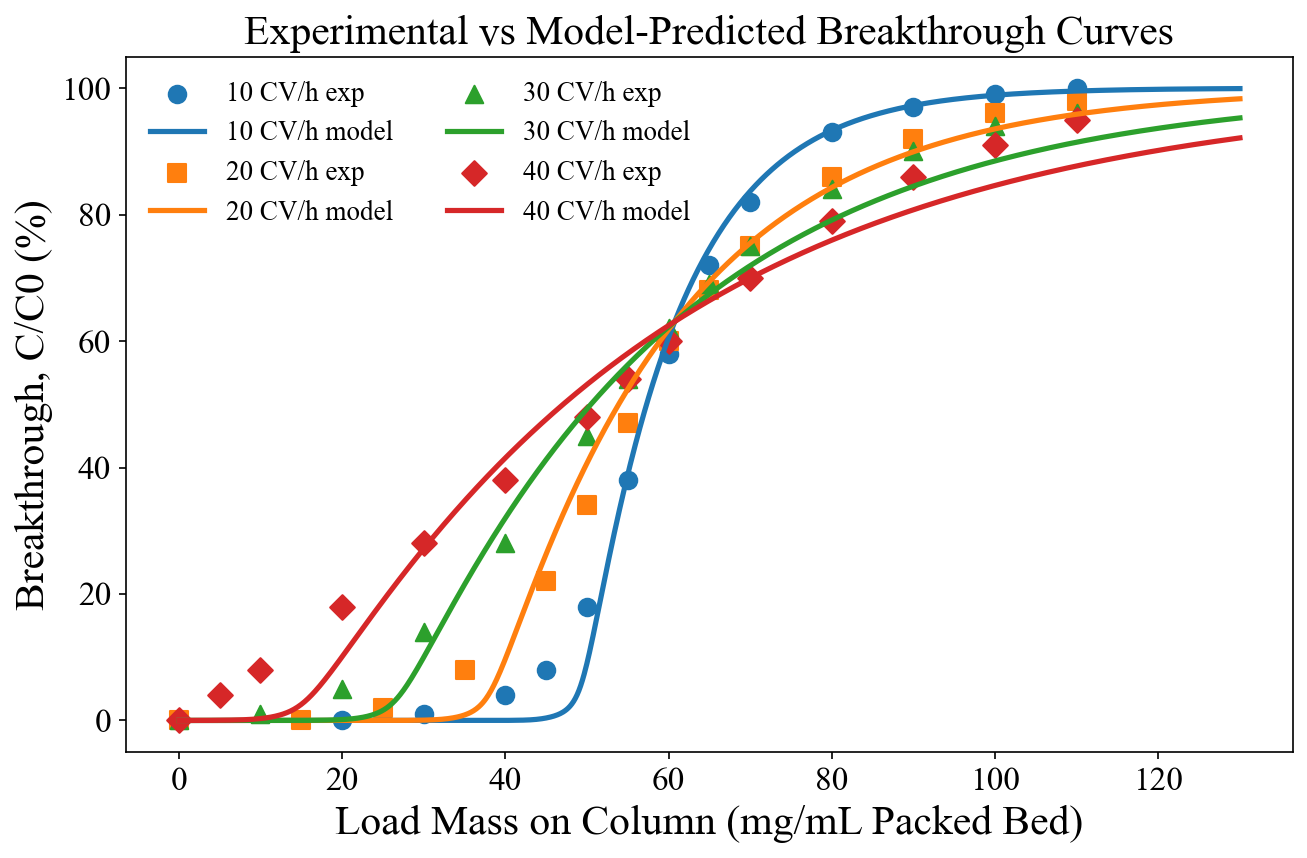


FIT ERROR SUMMARY BY FLOW RATE
               MAE      RMSE      Bias    MaxAbs
CV_per_h                                        
10        2.174773  3.507501 -0.986367  8.948844
20        2.686398  3.491097  0.192146  7.131146
30        3.266169  3.753648 -1.725782  5.514927
40        4.114293  4.859289 -1.949215  7.925327

PRODUCTIVITY TABLE
 residence_time_min  OBC_at_95_capture_mg_mL_bed  adsorbent_capacity_utilization_pct  t_load_min  t_nonload_min  total_cycle_time_min  productivity_excel_basis_g_L_resin_h  productivity_captured_g_L_resin_h  productivity_excel_basis_g_L_total_resin_h  productivity_captured_g_L_total_resin_h
                0.5                        0.824                               1.372       0.163            120               120.163                                 0.411                              0.391                                       0.206                                    0.195
                1.0                        1.353                      

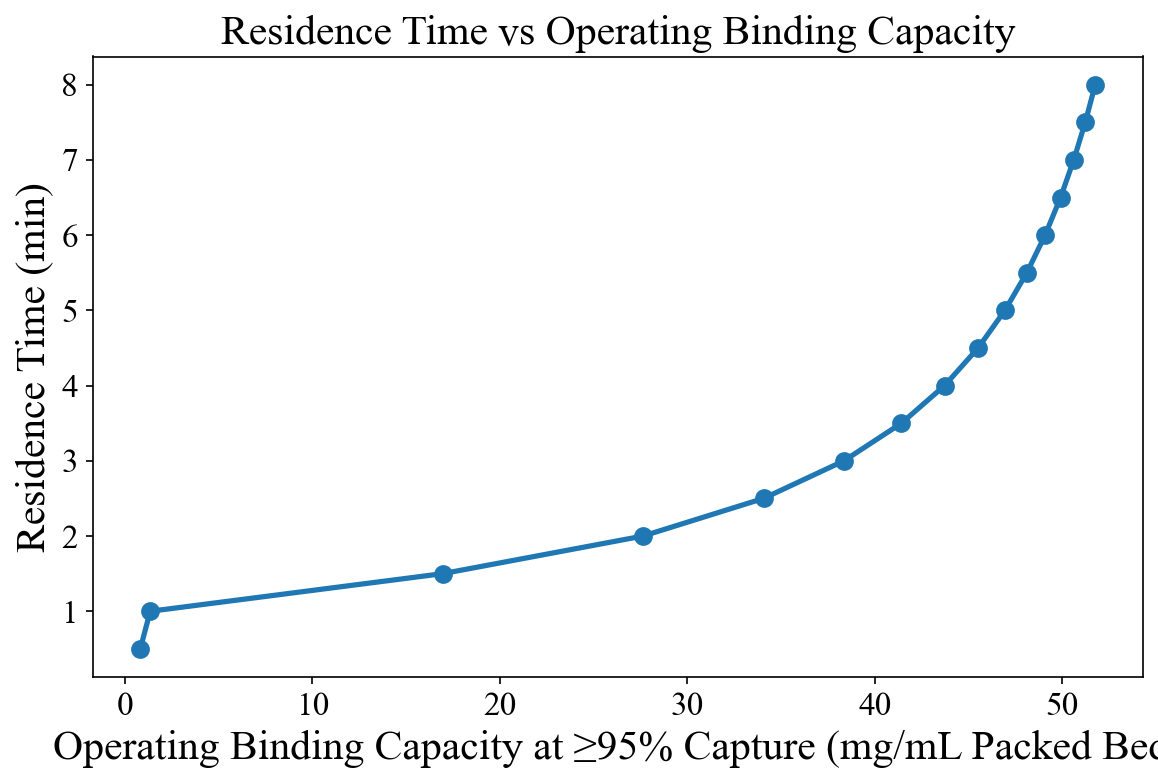

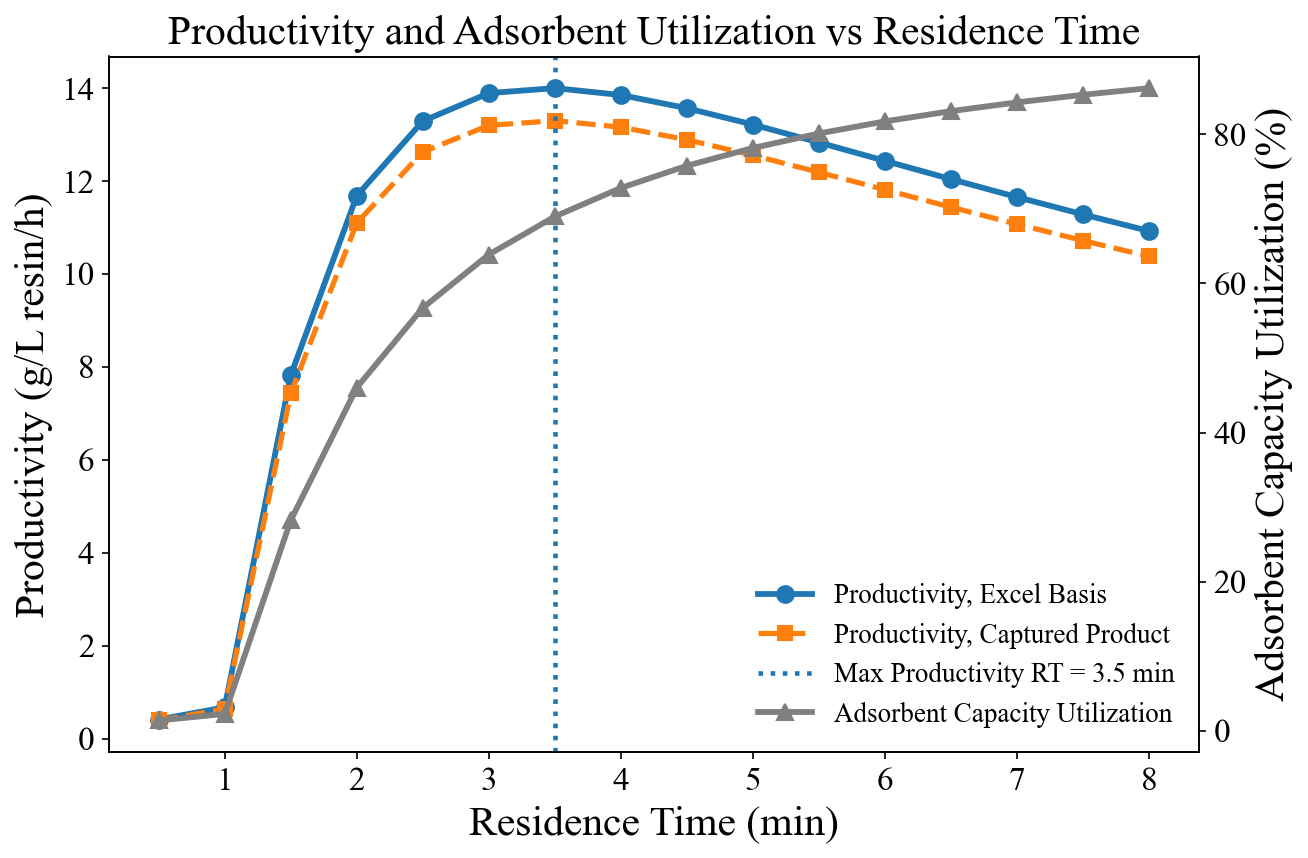

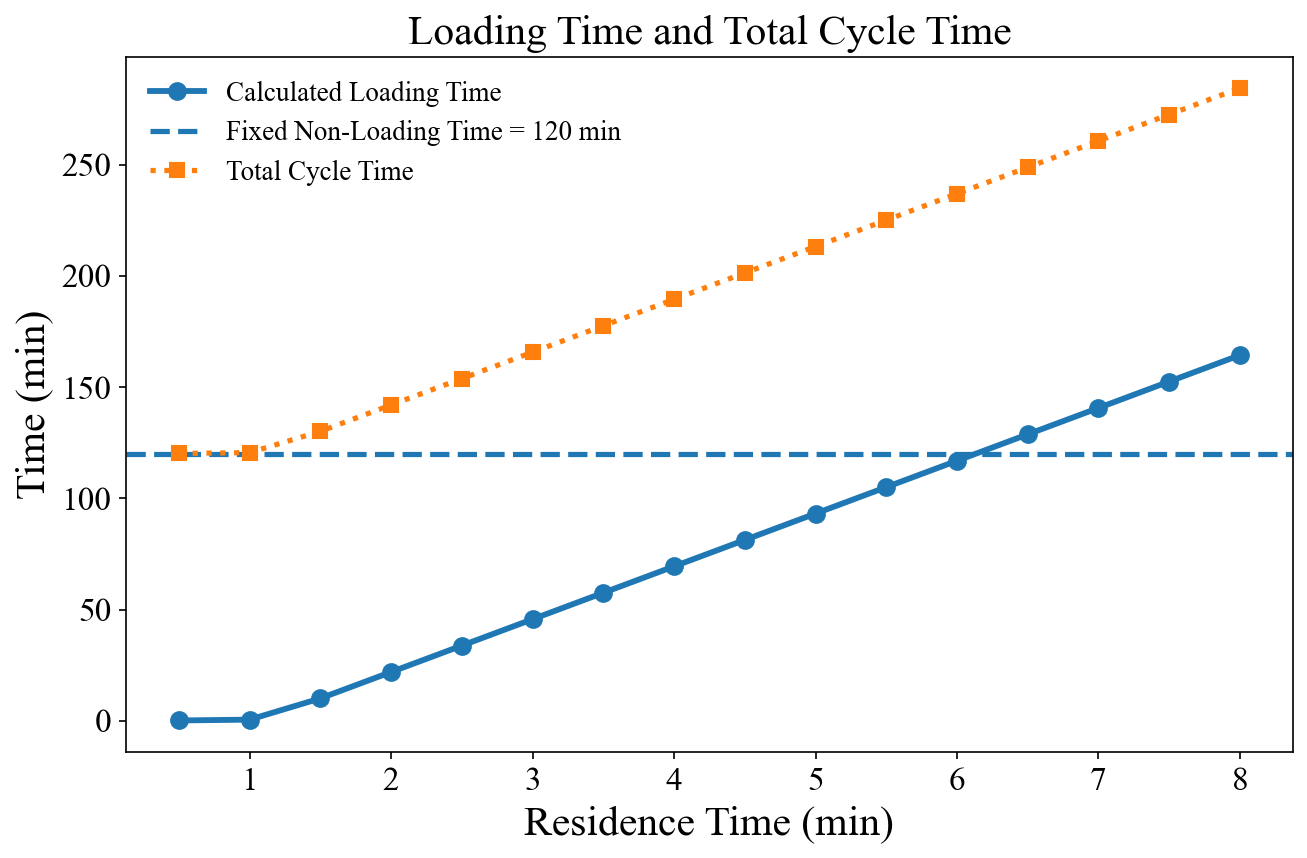


Files saved in:
/Users/vijaymaranholkar/Desktop/Amgen/output
output/experimental_vs_predicted_breakthrough_fit_PPT.png
output/RT_vs_OBC_95_capture_PPT.png
output/Productivity_and_Utilization_vs_RT_Excel_Basis_PPT.png
output/Loading_Nonloading_Total_Cycle_Time_PPT.png


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# PLOT STYLE FOR PPT
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["figure.dpi"] = 150

# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTDIR = Path("./output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DIGITIZED BREAKTHROUGH DATA
# MAb1 on MabSelect SuRe
# Approximate values from Figure 15.3
# ============================================================

digitized_data = {
    10: pd.DataFrame({
        "load_mg_mL_bed": [0, 20, 30, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  1,  4,  8, 18, 38, 58, 72, 82, 93, 97, 99, 100]
    }),
    20: pd.DataFrame({
        "load_mg_mL_bed": [0, 15, 25, 35, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  2,  8, 22, 34, 47, 60, 68, 75, 86, 92, 96, 98]
    }),
    30: pd.DataFrame({
        "load_mg_mL_bed": [0, 10, 20, 30, 40, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  1,  5, 14, 28, 45, 54, 62, 69, 75, 84, 90, 94, 96]
    }),
    40: pd.DataFrame({
        "load_mg_mL_bed": [0, 5, 10, 20, 30, 40, 50, 55, 60, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0, 4,  8, 18, 28, 38, 48, 54, 60, 70, 79, 86, 91, 95]
    })
}

# ============================================================
# COLUMN / FEED CONDITIONS
# ============================================================

feed_conc = 2.52          # mg/mL = g/L
capture_efficiency = 0.95

column_ID_cm = 1.6
bed_height_cm = 2.5

V_col_mL = np.pi * (column_ID_cm / 2)**2 * bed_height_cm
L_m = bed_height_cm / 100

eps = 0.41
dp_m = 85e-6
n_comp = 10

# Fixed non-loading time
t_nonload_fixed_min = 120   # 2 h

# ============================================================
# MODEL EQUATIONS
# ============================================================

def flow_from_CVh(CV_per_h):
    return CV_per_h * V_col_mL / 60.0


def k_from_Ds(Ds):
    rp = dp_m / 2
    return 15 * Ds / rp**2


def qeq(c, Qmax, b):
    c = np.maximum(c, 0)
    return Qmax * b * c / (1 + b * c)


def rhs_dispersion(t, y, F_mL_min, cfeed, Qmax, b, Ds, Dax):
    N = n_comp

    c = y[:N]
    q = y[N:]

    Vseg_mL = V_col_mL / N
    F_mL_s = F_mL_min / 60.0
    dz = L_m / N

    c_up = np.empty(N)
    c_up[0] = cfeed
    c_up[1:] = c[:-1]

    c_left = np.empty(N)
    c_right = np.empty(N)

    c_left[0] = cfeed
    c_left[1:] = c[:-1]

    c_right[:-1] = c[1:]
    c_right[-1] = c[-1]

    d2c = (c_left - 2*c + c_right) / dz**2

    k = k_from_Ds(Ds)
    mt = k * (qeq(c, Qmax, b) - q)

    dc = (
        (F_mL_s / (eps * Vseg_mL)) * (c_up - c)
        + (Dax / eps) * d2c
        - ((1 - eps) / eps) * mt
    )

    dq = mt

    return np.r_[dc, dq]


def simulate_breakthrough(CV_per_h, Qmax, b, Ds, Dax, max_load=130, n_points=1000):
    F_mL_min = flow_from_CVh(CV_per_h)

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)
    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax, b, Ds, Dax),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "CV_per_h": CV_per_h,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })

# ============================================================
# GLOBAL FIT TO 10, 20, 30, 40 CV/h
# ============================================================

def residuals(log_params):
    Qmax, b, Ds, Dax = np.exp(log_params)

    if not (
        70 < Qmax < 180 and
        1 < b < 300 and
        1e-15 < Ds < 1e-12 and
        1e-12 < Dax < 1e-6
    ):
        total_points = sum(len(df) for df in digitized_data.values())
        return np.ones(total_points + 4) * 1e6

    residual_list = []

    for CV_per_h, exp in digitized_data.items():

        sim = simulate_breakthrough(
            CV_per_h,
            Qmax,
            b,
            Ds,
            Dax,
            max_load=130,
            n_points=500
        )

        pred = np.interp(
            exp["load_mg_mL_bed"],
            sim["load_mg_mL_bed"],
            sim["c_over_c0_pct"]
        )

        residual_list.extend(
            pred - exp["c_over_c0_pct"].values
        )

    reg = [
        0.03 * (np.log(Qmax) - np.log(107)),
        0.03 * (np.log(b) - np.log(44)),
        0.03 * (np.log(Ds) - np.log(9.5e-14)),
        0.03 * (np.log(Dax) - np.log(4.4e-11)),
    ]

    return np.r_[residual_list, reg]


x0 = np.log([107, 44, 9.5e-14, 4.4e-11])

fit = least_squares(
    residuals,
    x0,
    max_nfev=80,
    xtol=1e-4,
    ftol=1e-4
)

Qmax_fit, b_fit, Ds_fit, Dax_fit = np.exp(fit.x)
SBC_mg_mL_bed = (1 - eps) * Qmax_fit

print("\nBEST-FIT PARAMETERS")
print(f"Qmax = {Qmax_fit:.4f} mg/mL bead")
print(f"b    = {b_fit:.4f} mL/mg")
print(f"Ds   = {Ds_fit:.4e} m²/s")
print(f"Dax  = {Dax_fit:.4e} m²/s")
print(f"kLDF = {k_from_Ds(Ds_fit):.4e} 1/s")
print(f"SBC  = {SBC_mg_mL_bed:.4f} mg/mL packed bed")

# ============================================================
# BREAKTHROUGH FITTING PLOT
# ============================================================

error_rows = []
model_rows = []

fig, ax = plt.subplots(figsize=(9, 6))

markers = {
    10: "o",
    20: "s",
    30: "^",
    40: "D"
}

for CV_per_h, exp in digitized_data.items():

    sim = simulate_breakthrough(
        CV_per_h,
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        max_load=130,
        n_points=1200
    )

    model_rows.append(sim)

    pred = np.interp(
        exp["load_mg_mL_bed"],
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"]
    )

    for x, y_exp, y_pred in zip(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        pred
    ):
        error_rows.append({
            "CV_per_h": CV_per_h,
            "load_mg_mL_bed": x,
            "experimental_C_C0_pct": y_exp,
            "predicted_C_C0_pct": y_pred,
            "error_pctpt": y_pred - y_exp
        })

    ax.scatter(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        marker=markers[CV_per_h],
        s=70,
        label=f"{CV_per_h} CV/h exp"
    )

    ax.plot(
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"],
        linewidth=2.5,
        label=f"{CV_per_h} CV/h model"
    )

ax.set_xlabel("Load Mass on Column (mg/mL Packed Bed)")
ax.set_ylabel("Breakthrough, C/C0 (%)")
ax.set_title("Experimental vs Model-Predicted Breakthrough Curves")
ax.legend(ncol=2, frameon=False)
ax.grid(False)

plt.tight_layout()
fit_plot_path = OUTDIR / "experimental_vs_predicted_breakthrough_fit_PPT.png"
plt.savefig(fit_plot_path, dpi=300, bbox_inches="tight")
plt.show()

error_df = pd.DataFrame(error_rows)
model_df = pd.concat(model_rows, ignore_index=True)

print("\nFIT ERROR SUMMARY BY FLOW RATE")
summary = error_df.groupby("CV_per_h")["error_pctpt"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Bias="mean",
    MaxAbs=lambda x: np.max(np.abs(x))
)
print(summary)

# ============================================================
# OBC AT 95% CAPTURE
# ============================================================

def simulate_breakthrough_RT(residence_time_min, max_load=160, n_points=1200):

    F_mL_min = V_col_mL / residence_time_min

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(
        0,
        t_end_min * 60,
        n_points
    )

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax_fit, b_fit, Ds_fit, Dax_fit),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "residence_time_min": residence_time_min,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


def find_load_at_breakthrough(residence_time_min, breakthrough_pct=5.0):

    sim = simulate_breakthrough_RT(
        residence_time_min,
        max_load=160,
        n_points=1200
    )

    x = sim["load_mg_mL_bed"].values
    y = sim["c_over_c0_pct"].values

    y_mono = np.maximum.accumulate(y)

    if breakthrough_pct < y_mono.min() or breakthrough_pct > y_mono.max():
        return np.nan

    return np.interp(
        breakthrough_pct,
        y_mono,
        x
    )


residence_times = np.arange(0.5, 8.0 + 0.001, 0.5)

obc_95 = [
    find_load_at_breakthrough(rt, breakthrough_pct=5.0)
    for rt in residence_times
]

obc_df = pd.DataFrame({
    "residence_time_min": residence_times,
    "OBC_at_95_capture_mg_mL_bed": obc_95
})

# ============================================================
# PRODUCTIVITY CALCULATION - EXCEL MATCHING BASIS
# ============================================================

obc_df["adsorbent_capacity_utilization_pct"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    / SBC_mg_mL_bed
    * 100
)

# Loading time
# OBC mg/mL = g/L; feed_conc mg/mL = g/L
obc_df["t_load_min"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * obc_df["residence_time_min"]
    / feed_conc
)

obc_df["t_nonload_min"] = t_nonload_fixed_min

# Excel-style total cycle time
obc_df["total_cycle_time_min"] = (
    obc_df["t_load_min"]
    + obc_df["t_nonload_min"]
)

# Excel basis: no capture correction, no divide by two
obc_df["productivity_excel_basis_g_L_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * 60
    / obc_df["total_cycle_time_min"]
)

# Captured product basis
obc_df["productivity_captured_g_L_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * capture_efficiency
    * 60
    / obc_df["total_cycle_time_min"]
)

# Total-resin basis for two columns
obc_df["productivity_excel_basis_g_L_total_resin_h"] = (
    obc_df["productivity_excel_basis_g_L_resin_h"]
    / 2
)

obc_df["productivity_captured_g_L_total_resin_h"] = (
    obc_df["productivity_captured_g_L_resin_h"]
    / 2
)

print("\nPRODUCTIVITY TABLE")
print(obc_df.round(3).to_string(index=False))

best_excel = obc_df.loc[
    obc_df["productivity_excel_basis_g_L_resin_h"].idxmax()
]

print("\nBEST PRODUCTIVITY CONDITION - EXCEL BASIS")
print(best_excel.round(3).to_string())

# ============================================================
# PLOT 1: RT VS OBC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    obc_df["OBC_at_95_capture_mg_mL_bed"],
    obc_df["residence_time_min"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.set_xlabel("Operating Binding Capacity at ≥95% Capture (mg/mL Packed Bed)")
ax.set_ylabel("Residence Time (min)")
ax.set_title("Residence Time vs Operating Binding Capacity")
ax.grid(False)

plt.tight_layout()
obc_plot_path = OUTDIR / "RT_vs_OBC_95_capture_PPT.png"
plt.savefig(obc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: PRODUCTIVITY + UTILIZATION SECONDARY AXIS
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["productivity_excel_basis_g_L_resin_h"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Productivity, Excel Basis"
)

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["productivity_captured_g_L_resin_h"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Productivity, Captured Product"
)

ax1.axvline(
    best_excel["residence_time_min"],
    linestyle=":",
    linewidth=2.2,
    label=f"Max Productivity RT = {best_excel['residence_time_min']:.1f} min"
)

ax1.set_xlabel("Residence Time (min)")
ax1.set_ylabel("Productivity (g/L resin/h)")
ax1.grid(False)

ax2 = ax1.twinx()

ax2.plot(
    obc_df["residence_time_min"],
    obc_df["adsorbent_capacity_utilization_pct"],
    marker="^",
    linewidth=2.8,
    markersize=8,
    color="gray",
    label="Adsorbent Capacity Utilization"
)

ax2.set_ylabel("Adsorbent Capacity Utilization (%)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="best"
)

plt.title("Productivity and Adsorbent Utilization vs Residence Time")
plt.tight_layout()

prod_util_plot_path = OUTDIR / "Productivity_and_Utilization_vs_RT_Excel_Basis_PPT.png"
plt.savefig(prod_util_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 3: LOADING AND NON-LOADING TIME
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    obc_df["residence_time_min"],
    obc_df["t_load_min"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Calculated Loading Time"
)

ax.axhline(
    t_nonload_fixed_min,
    linestyle="--",
    linewidth=2.5,
    label="Fixed Non-Loading Time = 120 min"
)

ax.plot(
    obc_df["residence_time_min"],
    obc_df["total_cycle_time_min"],
    marker="s",
    linestyle=":",
    linewidth=2.5,
    markersize=7,
    label="Total Cycle Time"
)

ax.set_xlabel("Residence Time (min)")
ax.set_ylabel("Time (min)")
ax.set_title("Loading Time and Total Cycle Time")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
time_plot_path = OUTDIR / "Loading_Nonloading_Total_Cycle_Time_PPT.png"
plt.savefig(time_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SAVE OUTPUTS
# ============================================================

params_df = pd.DataFrame({
    "parameter": ["Qmax", "b", "Ds", "Dax", "kLDF", "SBC"],
    "value": [
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        k_from_Ds(Ds_fit),
        SBC_mg_mL_bed
    ],
    "unit": [
        "mg/mL bead",
        "mL/mg",
        "m²/s",
        "m²/s",
        "1/s",
        "mg/mL packed bed"
    ]
})

params_df.to_csv(
    OUTDIR / "best_fit_parameters.csv",
    index=False
)

error_df.to_csv(
    OUTDIR / "experimental_vs_predicted_values.csv",
    index=False
)

model_df.to_csv(
    OUTDIR / "predicted_breakthrough_curves.csv",
    index=False
)

obc_df.to_csv(
    OUTDIR / "productivity_table_excel_basis.csv",
    index=False
)

print("\nFiles saved in:")
print(OUTDIR.resolve())
print(fit_plot_path)
print(obc_plot_path)
print(prod_util_plot_path)
print(time_plot_path)


BEST-FIT PARAMETERS
Qmax = 101.7691 mg/mL bead
b    = 47.4290 mL/mg
Ds   = 7.5816e-14 m²/s
Dax  = 3.6202e-11 m²/s
kLDF = 6.2962e-04 1/s
SBC  = 60.0438 mg/mL packed bed


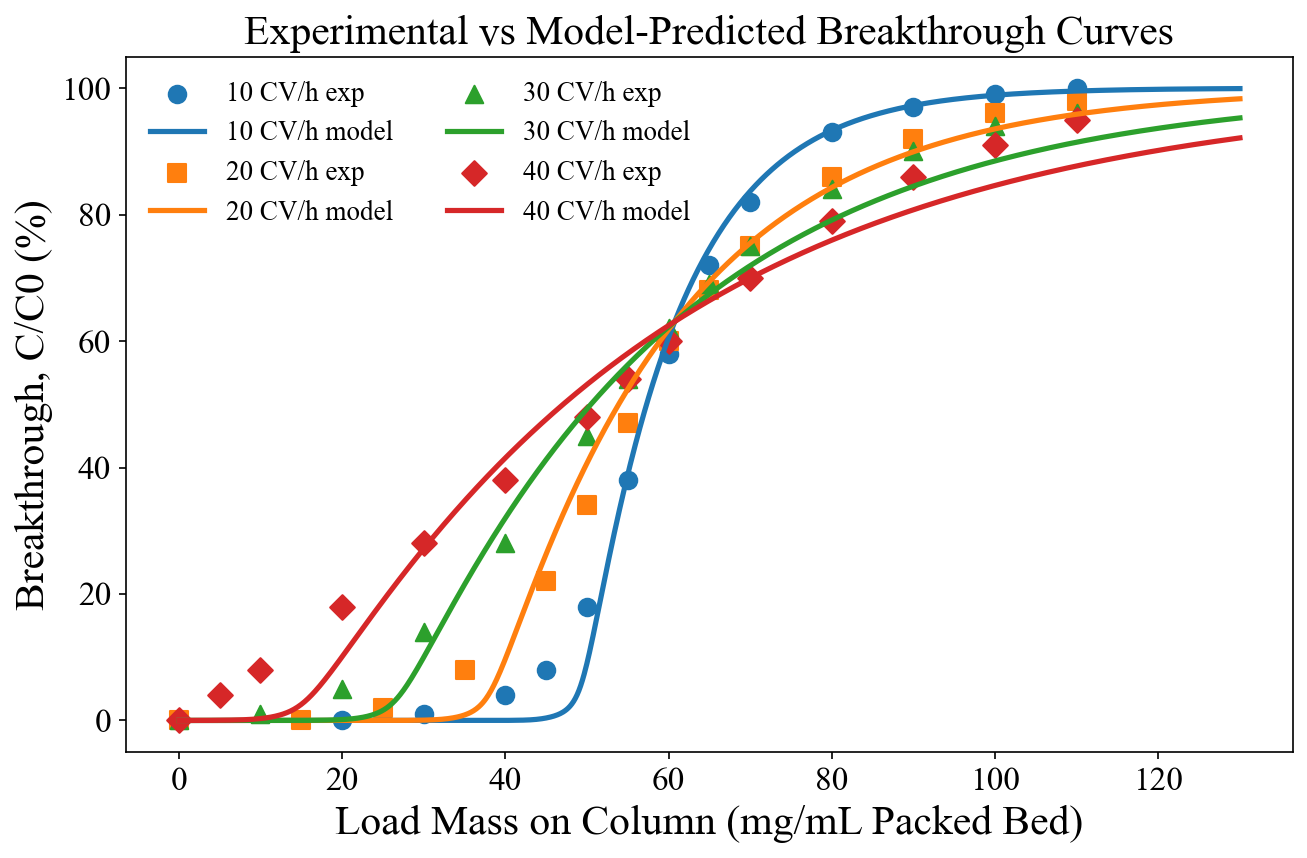


FIT ERROR SUMMARY BY FLOW RATE
               MAE      RMSE      Bias    MaxAbs
CV_per_h                                        
10        2.174773  3.507501 -0.986367  8.948844
20        2.686398  3.491097  0.192146  7.131146
30        3.266169  3.753648 -1.725782  5.514927
40        4.114293  4.859289 -1.949215  7.925327

MODEL-PREDICTED PRODUCTIVITY TABLE
 residence_time_min  OBC_at_95_capture_mg_mL_bed  adsorbent_capacity_utilization_pct  t_load_min  t_nonload_min  total_cycle_time_min  model_predicted_productivity_g_L_resin_h  model_predicted_captured_productivity_g_L_resin_h  model_predicted_productivity_g_L_total_resin_h  model_predicted_captured_productivity_g_L_total_resin_h
                0.5                        0.824                               1.372       0.163            120               120.163                                     0.411                                              0.391                                           0.206                                

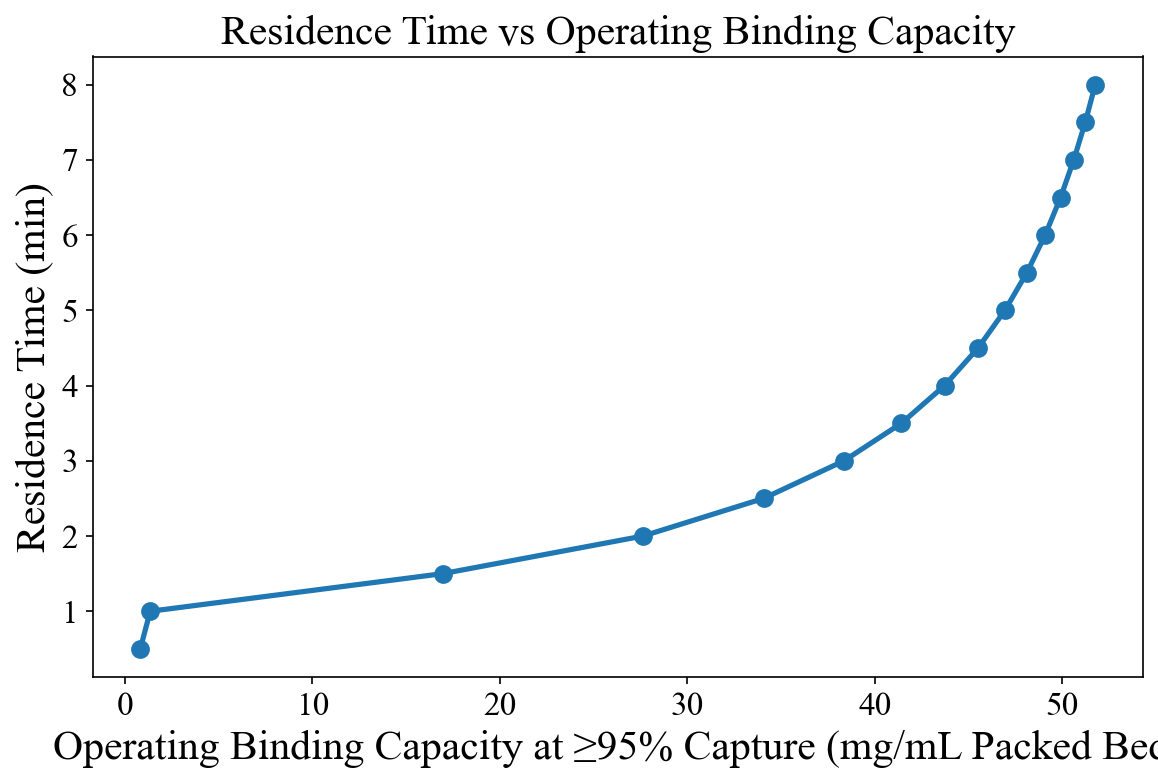

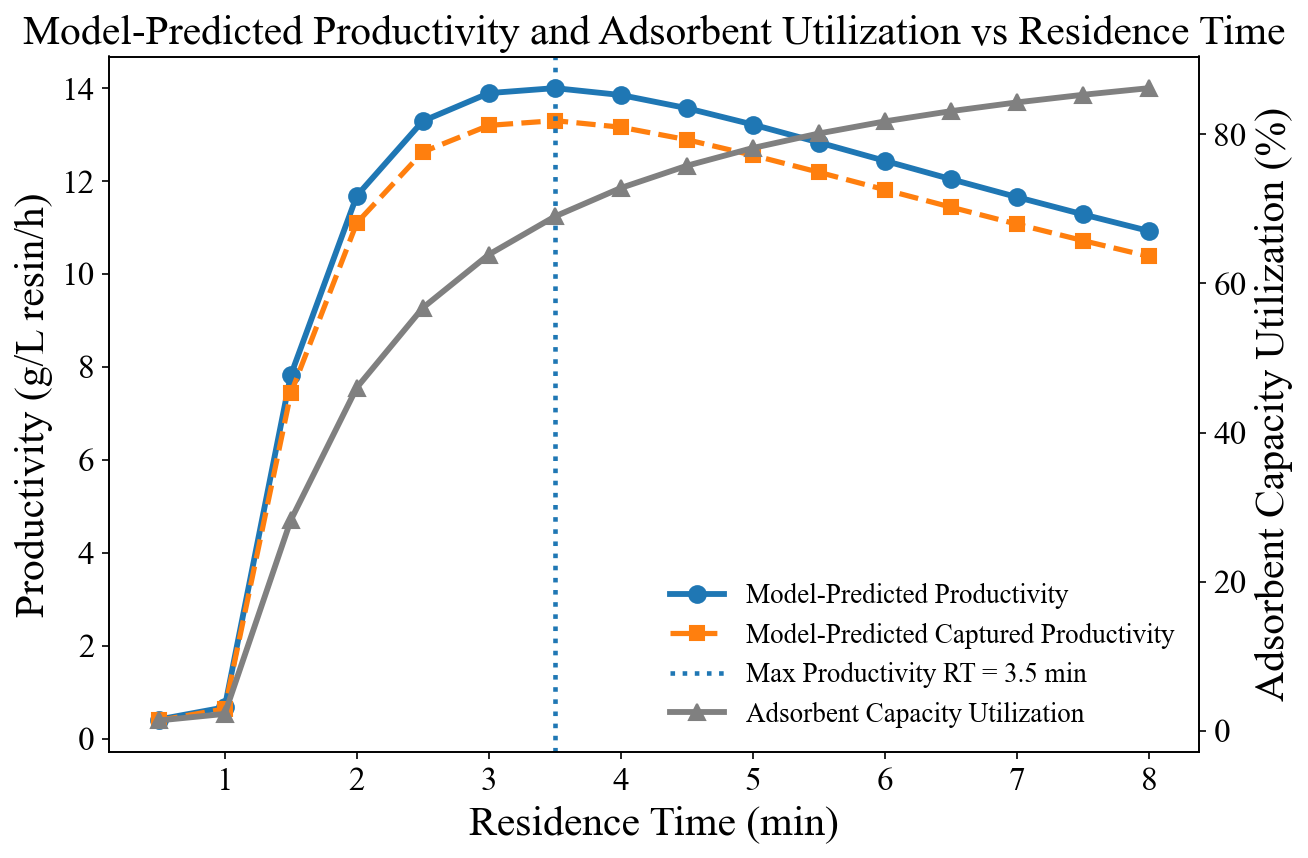

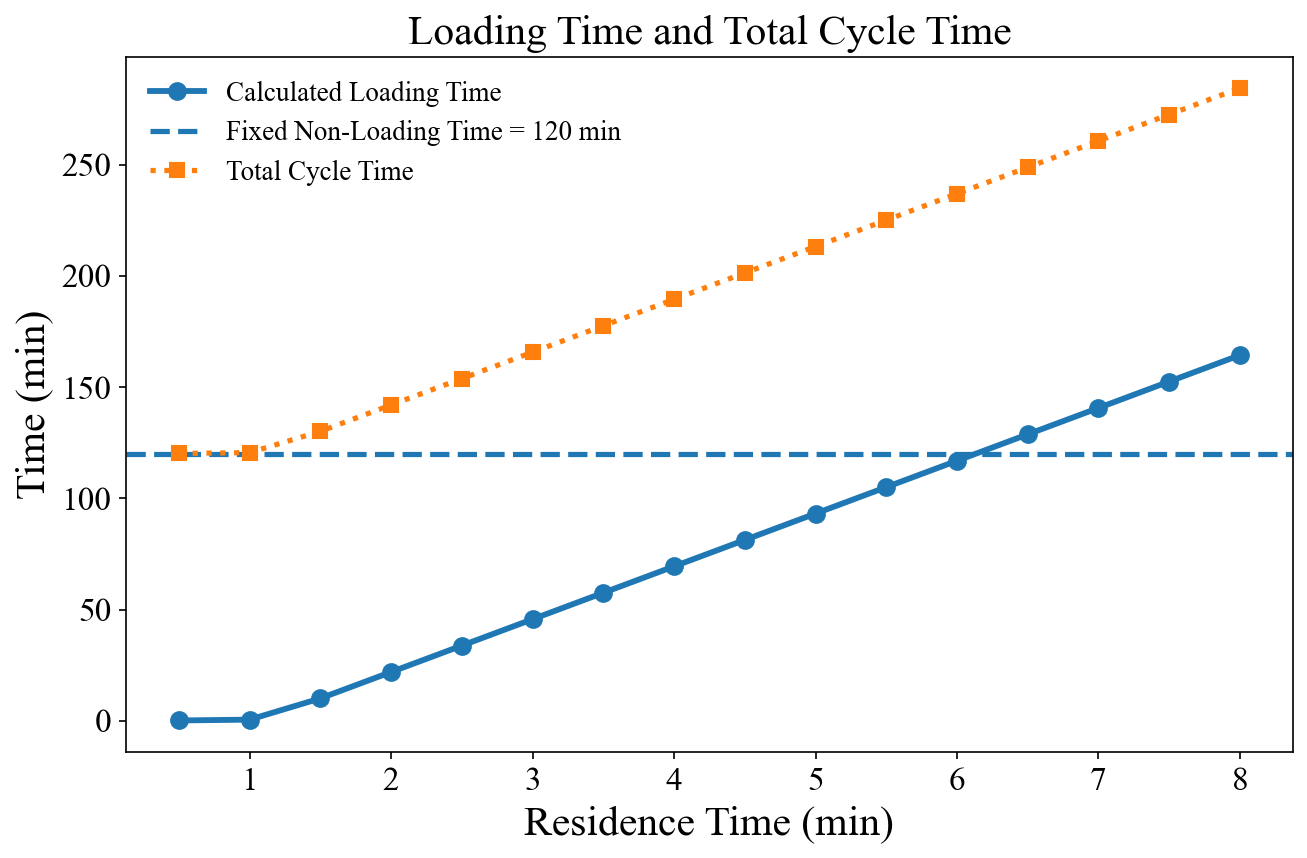


Files saved in:
/Users/vijaymaranholkar/Desktop/Amgen/output
output/experimental_vs_predicted_breakthrough_fit_PPT.png
output/RT_vs_OBC_95_capture_PPT.png
output/Model_Predicted_Productivity_and_Utilization_vs_RT_PPT.png
output/Loading_Nonloading_Total_Cycle_Time_PPT.png


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# PLOT STYLE FOR PPT
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["figure.dpi"] = 150

# ============================================================
# OUTPUT FOLDER
# ============================================================

OUTDIR = Path("./output")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DIGITIZED BREAKTHROUGH DATA
# MAb1 on MabSelect SuRe
# Approximate values from Figure 15.3
# ============================================================

digitized_data = {
    10: pd.DataFrame({
        "load_mg_mL_bed": [0, 20, 30, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  1,  4,  8, 18, 38, 58, 72, 82, 93, 97, 99, 100]
    }),
    20: pd.DataFrame({
        "load_mg_mL_bed": [0, 15, 25, 35, 45, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  0,  2,  8, 22, 34, 47, 60, 68, 75, 86, 92, 96, 98]
    }),
    30: pd.DataFrame({
        "load_mg_mL_bed": [0, 10, 20, 30, 40, 50, 55, 60, 65, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0,  1,  5, 14, 28, 45, 54, 62, 69, 75, 84, 90, 94, 96]
    }),
    40: pd.DataFrame({
        "load_mg_mL_bed": [0, 5, 10, 20, 30, 40, 50, 55, 60, 70, 80, 90, 100, 110],
        "c_over_c0_pct":  [0, 4,  8, 18, 28, 38, 48, 54, 60, 70, 79, 86, 91, 95]
    })
}

# ============================================================
# COLUMN / FEED CONDITIONS
# ============================================================

feed_conc = 2.52          # mg/mL = g/L
capture_efficiency = 0.95

column_ID_cm = 1.6
bed_height_cm = 2.5

V_col_mL = np.pi * (column_ID_cm / 2)**2 * bed_height_cm
L_m = bed_height_cm / 100

eps = 0.41
dp_m = 85e-6
n_comp = 10

# Fixed non-loading time
t_nonload_fixed_min = 120   # 2 h

# ============================================================
# MODEL EQUATIONS
# ============================================================

def flow_from_CVh(CV_per_h):
    return CV_per_h * V_col_mL / 60.0


def k_from_Ds(Ds):
    rp = dp_m / 2
    return 15 * Ds / rp**2


def qeq(c, Qmax, b):
    c = np.maximum(c, 0)
    return Qmax * b * c / (1 + b * c)


def rhs_dispersion(t, y, F_mL_min, cfeed, Qmax, b, Ds, Dax):
    N = n_comp

    c = y[:N]
    q = y[N:]

    Vseg_mL = V_col_mL / N
    F_mL_s = F_mL_min / 60.0
    dz = L_m / N

    c_up = np.empty(N)
    c_up[0] = cfeed
    c_up[1:] = c[:-1]

    c_left = np.empty(N)
    c_right = np.empty(N)

    c_left[0] = cfeed
    c_left[1:] = c[:-1]

    c_right[:-1] = c[1:]
    c_right[-1] = c[-1]

    d2c = (c_left - 2*c + c_right) / dz**2

    k = k_from_Ds(Ds)
    mt = k * (qeq(c, Qmax, b) - q)

    dc = (
        (F_mL_s / (eps * Vseg_mL)) * (c_up - c)
        + (Dax / eps) * d2c
        - ((1 - eps) / eps) * mt
    )

    dq = mt

    return np.r_[dc, dq]


def simulate_breakthrough(CV_per_h, Qmax, b, Ds, Dax, max_load=130, n_points=1000):
    F_mL_min = flow_from_CVh(CV_per_h)

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(0, t_end_min * 60, n_points)
    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax, b, Ds, Dax),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "CV_per_h": CV_per_h,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })

# ============================================================
# GLOBAL FIT TO 10, 20, 30, 40 CV/h
# ============================================================

def residuals(log_params):
    Qmax, b, Ds, Dax = np.exp(log_params)

    if not (
        70 < Qmax < 180 and
        1 < b < 300 and
        1e-15 < Ds < 1e-12 and
        1e-12 < Dax < 1e-6
    ):
        total_points = sum(len(df) for df in digitized_data.values())
        return np.ones(total_points + 4) * 1e6

    residual_list = []

    for CV_per_h, exp in digitized_data.items():

        sim = simulate_breakthrough(
            CV_per_h,
            Qmax,
            b,
            Ds,
            Dax,
            max_load=130,
            n_points=500
        )

        pred = np.interp(
            exp["load_mg_mL_bed"],
            sim["load_mg_mL_bed"],
            sim["c_over_c0_pct"]
        )

        residual_list.extend(
            pred - exp["c_over_c0_pct"].values
        )

    reg = [
        0.03 * (np.log(Qmax) - np.log(107)),
        0.03 * (np.log(b) - np.log(44)),
        0.03 * (np.log(Ds) - np.log(9.5e-14)),
        0.03 * (np.log(Dax) - np.log(4.4e-11)),
    ]

    return np.r_[residual_list, reg]


x0 = np.log([107, 44, 9.5e-14, 4.4e-11])

fit = least_squares(
    residuals,
    x0,
    max_nfev=80,
    xtol=1e-4,
    ftol=1e-4
)

Qmax_fit, b_fit, Ds_fit, Dax_fit = np.exp(fit.x)
SBC_mg_mL_bed = (1 - eps) * Qmax_fit

print("\nBEST-FIT PARAMETERS")
print(f"Qmax = {Qmax_fit:.4f} mg/mL bead")
print(f"b    = {b_fit:.4f} mL/mg")
print(f"Ds   = {Ds_fit:.4e} m²/s")
print(f"Dax  = {Dax_fit:.4e} m²/s")
print(f"kLDF = {k_from_Ds(Ds_fit):.4e} 1/s")
print(f"SBC  = {SBC_mg_mL_bed:.4f} mg/mL packed bed")

# ============================================================
# BREAKTHROUGH FITTING PLOT
# ============================================================

error_rows = []
model_rows = []

fig, ax = plt.subplots(figsize=(9, 6))

markers = {
    10: "o",
    20: "s",
    30: "^",
    40: "D"
}

for CV_per_h, exp in digitized_data.items():

    sim = simulate_breakthrough(
        CV_per_h,
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        max_load=130,
        n_points=1200
    )

    model_rows.append(sim)

    pred = np.interp(
        exp["load_mg_mL_bed"],
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"]
    )

    for x, y_exp, y_pred in zip(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        pred
    ):
        error_rows.append({
            "CV_per_h": CV_per_h,
            "load_mg_mL_bed": x,
            "experimental_C_C0_pct": y_exp,
            "predicted_C_C0_pct": y_pred,
            "error_pctpt": y_pred - y_exp
        })

    ax.scatter(
        exp["load_mg_mL_bed"],
        exp["c_over_c0_pct"],
        marker=markers[CV_per_h],
        s=70,
        label=f"{CV_per_h} CV/h exp"
    )

    ax.plot(
        sim["load_mg_mL_bed"],
        sim["c_over_c0_pct"],
        linewidth=2.5,
        label=f"{CV_per_h} CV/h model"
    )

ax.set_xlabel("Load Mass on Column (mg/mL Packed Bed)")
ax.set_ylabel("Breakthrough, C/C0 (%)")
ax.set_title("Experimental vs Model-Predicted Breakthrough Curves")
ax.legend(ncol=2, frameon=False)
ax.grid(False)

plt.tight_layout()
fit_plot_path = OUTDIR / "experimental_vs_predicted_breakthrough_fit_PPT.png"
plt.savefig(fit_plot_path, dpi=300, bbox_inches="tight")
plt.show()

error_df = pd.DataFrame(error_rows)
model_df = pd.concat(model_rows, ignore_index=True)

print("\nFIT ERROR SUMMARY BY FLOW RATE")
summary = error_df.groupby("CV_per_h")["error_pctpt"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Bias="mean",
    MaxAbs=lambda x: np.max(np.abs(x))
)
print(summary)

# ============================================================
# OBC AT 95% CAPTURE
# ============================================================

def simulate_breakthrough_RT(residence_time_min, max_load=160, n_points=1200):

    F_mL_min = V_col_mL / residence_time_min

    t_end_min = max_load * V_col_mL / (F_mL_min * feed_conc)

    t_eval = np.linspace(
        0,
        t_end_min * 60,
        n_points
    )

    y0 = np.zeros(2 * n_comp)

    sol = solve_ivp(
        rhs_dispersion,
        [0, t_end_min * 60],
        y0,
        args=(F_mL_min, feed_conc, Qmax_fit, b_fit, Ds_fit, Dax_fit),
        method="BDF",
        t_eval=t_eval,
        rtol=5e-5,
        atol=1e-7
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    c_out = sol.y[n_comp - 1]

    load = (
        F_mL_min *
        feed_conc *
        (sol.t / 60)
        / V_col_mL
    )

    return pd.DataFrame({
        "residence_time_min": residence_time_min,
        "load_mg_mL_bed": load,
        "c_over_c0_pct": 100 * c_out / feed_conc
    })


def find_load_at_breakthrough(residence_time_min, breakthrough_pct=5.0):

    sim = simulate_breakthrough_RT(
        residence_time_min,
        max_load=160,
        n_points=1200
    )

    x = sim["load_mg_mL_bed"].values
    y = sim["c_over_c0_pct"].values

    y_mono = np.maximum.accumulate(y)

    if breakthrough_pct < y_mono.min() or breakthrough_pct > y_mono.max():
        return np.nan

    return np.interp(
        breakthrough_pct,
        y_mono,
        x
    )


residence_times = np.arange(0.5, 8.0 + 0.001, 0.5)

obc_95 = [
    find_load_at_breakthrough(rt, breakthrough_pct=5.0)
    for rt in residence_times
]

obc_df = pd.DataFrame({
    "residence_time_min": residence_times,
    "OBC_at_95_capture_mg_mL_bed": obc_95
})

# ============================================================
# MODEL-PREDICTED PRODUCTIVITY CALCULATION
# ============================================================

obc_df["adsorbent_capacity_utilization_pct"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    / SBC_mg_mL_bed
    * 100
)

# Loading time
# OBC mg/mL = g/L resin
# feed_conc mg/mL = g/L feed
obc_df["t_load_min"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * obc_df["residence_time_min"]
    / feed_conc
)

obc_df["t_nonload_min"] = t_nonload_fixed_min

# Total cycle time = loading time + fixed non-loading time
obc_df["total_cycle_time_min"] = (
    obc_df["t_load_min"]
    + obc_df["t_nonload_min"]
)

# Model-predicted productivity, processed product basis
obc_df["model_predicted_productivity_g_L_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * 60
    / obc_df["total_cycle_time_min"]
)

# Model-predicted productivity, captured product basis
obc_df["model_predicted_captured_productivity_g_L_resin_h"] = (
    obc_df["OBC_at_95_capture_mg_mL_bed"]
    * capture_efficiency
    * 60
    / obc_df["total_cycle_time_min"]
)

# Optional: total resin basis for two-column system
obc_df["model_predicted_productivity_g_L_total_resin_h"] = (
    obc_df["model_predicted_productivity_g_L_resin_h"]
    / 2
)

obc_df["model_predicted_captured_productivity_g_L_total_resin_h"] = (
    obc_df["model_predicted_captured_productivity_g_L_resin_h"]
    / 2
)

print("\nMODEL-PREDICTED PRODUCTIVITY TABLE")
print(obc_df.round(3).to_string(index=False))

best_model = obc_df.loc[
    obc_df["model_predicted_productivity_g_L_resin_h"].idxmax()
]

print("\nBEST MODEL-PREDICTED PRODUCTIVITY CONDITION")
print(best_model.round(3).to_string())

# ============================================================
# PLOT 1: RT VS OBC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    obc_df["OBC_at_95_capture_mg_mL_bed"],
    obc_df["residence_time_min"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.set_xlabel("Operating Binding Capacity at ≥95% Capture (mg/mL Packed Bed)")
ax.set_ylabel("Residence Time (min)")
ax.set_title("Residence Time vs Operating Binding Capacity")
ax.grid(False)

plt.tight_layout()
obc_plot_path = OUTDIR / "RT_vs_OBC_95_capture_PPT.png"
plt.savefig(obc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: MODEL-PREDICTED PRODUCTIVITY + UTILIZATION
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["model_predicted_productivity_g_L_resin_h"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Model-Predicted Productivity"
)

ax1.plot(
    obc_df["residence_time_min"],
    obc_df["model_predicted_captured_productivity_g_L_resin_h"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Model-Predicted Captured Productivity"
)

ax1.axvline(
    best_model["residence_time_min"],
    linestyle=":",
    linewidth=2.2,
    label=f"Max Productivity RT = {best_model['residence_time_min']:.1f} min"
)

ax1.set_xlabel("Residence Time (min)")
ax1.set_ylabel("Productivity (g/L resin/h)")
ax1.grid(False)

ax2 = ax1.twinx()

ax2.plot(
    obc_df["residence_time_min"],
    obc_df["adsorbent_capacity_utilization_pct"],
    marker="^",
    linewidth=2.8,
    markersize=8,
    color="gray",
    label="Adsorbent Capacity Utilization"
)

ax2.set_ylabel("Adsorbent Capacity Utilization (%)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="best"
)

plt.title("Model-Predicted Productivity and Adsorbent Utilization vs Residence Time")
plt.tight_layout()

prod_util_plot_path = OUTDIR / "Model_Predicted_Productivity_and_Utilization_vs_RT_PPT.png"
plt.savefig(prod_util_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 3: LOADING AND NON-LOADING TIME
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    obc_df["residence_time_min"],
    obc_df["t_load_min"],
    marker="o",
    linewidth=2.8,
    markersize=8,
    label="Calculated Loading Time"
)

ax.axhline(
    t_nonload_fixed_min,
    linestyle="--",
    linewidth=2.5,
    label="Fixed Non-Loading Time = 120 min"
)

ax.plot(
    obc_df["residence_time_min"],
    obc_df["total_cycle_time_min"],
    marker="s",
    linestyle=":",
    linewidth=2.5,
    markersize=7,
    label="Total Cycle Time"
)

ax.set_xlabel("Residence Time (min)")
ax.set_ylabel("Time (min)")
ax.set_title("Loading Time and Total Cycle Time")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
time_plot_path = OUTDIR / "Loading_Nonloading_Total_Cycle_Time_PPT.png"
plt.savefig(time_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SAVE OUTPUTS
# ============================================================

params_df = pd.DataFrame({
    "parameter": ["Qmax", "b", "Ds", "Dax", "kLDF", "SBC"],
    "value": [
        Qmax_fit,
        b_fit,
        Ds_fit,
        Dax_fit,
        k_from_Ds(Ds_fit),
        SBC_mg_mL_bed
    ],
    "unit": [
        "mg/mL bead",
        "mL/mg",
        "m²/s",
        "m²/s",
        "1/s",
        "mg/mL packed bed"
    ]
})

params_df.to_csv(
    OUTDIR / "best_fit_parameters.csv",
    index=False
)

error_df.to_csv(
    OUTDIR / "experimental_vs_predicted_values.csv",
    index=False
)

model_df.to_csv(
    OUTDIR / "predicted_breakthrough_curves.csv",
    index=False
)

obc_df.to_csv(
    OUTDIR / "model_predicted_productivity_table.csv",
    index=False
)

print("\nFiles saved in:")
print(OUTDIR.resolve())
print(fit_plot_path)
print(obc_plot_path)
print(prod_util_plot_path)
print(time_plot_path)